# Reading the Brain Under Anaesthesia: EEG Spectral Analysis

## Why should anaesthesiologists care about brain waves?

Every time you administer a general anaesthetic, you are performing one of the most profound interventions in medicine — you are switching off consciousness. But how do you *know* the brain is truly "off"? And how deep is too deep?

The answer lies in the **electroencephalogram (EEG)** — the electrical signal recorded from the scalp — which is our only real-time window into what the brain is doing during surgery. If you use a **Bispectral Index (BIS)** monitor, you are already using EEG analysis every day, perhaps without realising it. The BIS monitor records raw brain waves, processes them mathematically, and distils the result into a single number between 0 and 100. That number guides your titration of anaesthetic drugs, helps you avoid awareness under anaesthesia, and warns you when the brain is dangerously suppressed.

But that single number hides a rich story. In this chapter, we will look *behind* the BIS number and directly analyse the raw EEG signals from real surgical cases in the VitalDB dataset. You will see for yourself how anaesthetic drugs reshape brain electrical activity — and you will learn to read these patterns like a clinician who truly understands what is happening inside the patient's skull.

---

### What is an EEG?

An **electroencephalogram (EEG)** is simply a recording of the tiny electrical voltages generated by populations of neurons firing together in the cerebral cortex. These voltages are measured in *microvolts* (µV) — about one-millionth of a volt — and are picked up by electrodes placed on the scalp.

Think of it as an electrical "hum" produced by the brain. When you are awake and alert, this hum is **fast and irregular** — many different brain regions are chattering away independently, producing a complex, low-amplitude signal. Under anaesthesia, the picture changes dramatically: the hum becomes **slow, rhythmic, and powerful** — rather like the difference between a bustling café and a slow, steady drumbeat.

### What is spectral analysis?

**Spectral analysis** is the key technique we will use throughout this chapter. Here is the core idea:

Any complex, wiggly EEG signal can be mathematically decomposed into a collection of simple sine waves of different frequencies. Imagine **a prism splitting white light into its component colours** — red, orange, yellow, green, blue, violet. Spectral analysis does the same thing, but for brain waves instead of light. It takes the complex EEG squiggle and separates it into its component "colours" (frequencies), telling us *how much energy* the brain is producing at each frequency.

The mathematical tool that performs this decomposition is called the **Fourier transform**. You do not need to understand the mathematics — just the concept: we are breaking a complex wave into simple sine waves and measuring how much of each frequency is present.

We group these frequencies into clinically meaningful **bands**:

| Band | Frequency range | What does it mean clinically? |
|------|----------------|-------------------------------|
| **Delta** (δ) | 0.5–4 Hz | The slowest waves. Dominant in deep sleep and deep anaesthesia. Think of slow ocean swells. |
| **Theta** (θ) | 4–8 Hz | Light sleep, sedation, some stages of anaesthetic induction. |
| **Alpha** (α) | 8–13 Hz | Relaxed wakefulness (eyes closed), and importantly, a hallmark of moderate-depth propofol anaesthesia ("frontal alpha"). |
| **Beta** (β) | 13–30 Hz | Active thinking, alertness, and paradoxically, sometimes light sedation (beta activation). |
| **Gamma** (γ) | 30–45 Hz | Higher cognitive processing and sensory binding. Largely suppressed under anaesthesia. |

Under general anaesthesia, power shifts dramatically from the fast frequencies (beta, gamma) towards the slow frequencies (delta, theta), with a characteristic increase in **frontal alpha activity** at moderate anaesthetic depth — a pattern that is especially prominent with propofol.

Two more terms you will encounter:

- **Power spectral density (PSD):** A plot showing how much electrical energy (power) the brain produces at each frequency. It is the "frequency fingerprint" of the brain's electrical state.
- **Spectral edge frequency (SEF95):** The frequency below which 95% of the total EEG power lies. Under deep anaesthesia, this number drops because power shifts to slow frequencies.

### What you will learn

By the end of this chapter, you will be able to:

- **Understand raw EEG signals** — what they look like, how we clean them, and what "good quality" means
- **Read a power spectral density (PSD) plot** — the "frequency fingerprint" of the anaesthetised brain
- **Interpret a spectrogram** — a colour map showing how the brain's frequency content changes over the course of surgery
- **Recognise burst suppression** — a pattern of dangerously deep anaesthesia where the brain intermittently goes electrically silent
- **Track anaesthetic depth using band power** — watching delta, alpha, and other bands wax and wane as anaesthetic depth changes
- **Compare EEG signatures across patients and anaesthetic agents** — propofol versus volatile anaesthetics

We will work with real intraoperative EEG data from 8 surgical cases in the VitalDB dataset, recorded at 128 Hz from BIS monitor channels.

No prior knowledge of signal processing or advanced mathematics is required — we will build every concept from first principles.

## Setting up our tools

Before we can analyse EEG signals, we need to import our Python tools and set some constants. The key settings to note:

- **Sampling rate (Fs = 128 Hz):** The BIS monitor records EEG at 128 samples per second — more than enough to capture brain waves up to 45 Hz.
- **Epoch length (4 seconds):** We will analyse the EEG in 4-second "chunks" called epochs. This gives us good frequency resolution while still being short enough to track changes over time.
- **Frequency bands:** We define the five standard EEG bands (delta, theta, alpha, beta, gamma) with their frequency ranges, matching the table in our introduction.

In [1]:
# ── Cell 1: Setup & imports ──────────────────────────────────────────────────
import os, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import requests
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy import signal as sp_signal
from scipy.signal import butter, filtfilt, welch, coherence, spectrogram

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Paths
BASE       = Path('/Volumes/iDrisAI/VitalDBGit')
TRACKS_CSV = BASE / 'vital_db' / 'tracks.csv'
CASES_CSV  = BASE / 'vital_db' / 'all_cases.csv'
EEG_CACHE  = BASE / 'eeg_cache'
EEG_CACHE.mkdir(exist_ok=True)
API_BASE   = 'https://api.vitaldb.net'

# EEG signal constants
FS              = 128.0          # Hz — BIS monitor EEG sampling rate
EPOCH_S         = 4.0            # seconds per analysis epoch
EPOCH_N         = int(FS * EPOCH_S)  # 512 samples
N_CASES         = 8              # cases to load for analysis
MAX_ANALYSIS_MIN = 30            # cap for compute-heavy cells (minutes)
MAX_ANALYSIS_N   = int(MAX_ANALYSIS_MIN * 60 * FS)  # 230,400 samples

# EEG frequency bands (Hz)
BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta' : (13.0, 30.0),
    'gamma': (30.0, 45.0),
}
BAND_COLORS = {'delta':'#4878CF','theta':'#6ACC65','alpha':'#D65F5F',
               'beta':'#B47CC7','gamma':'#C4AD66'}

print('Setup complete.')
print(f'  EEG Fs = {FS} Hz | Epoch = {EPOCH_S}s ({EPOCH_N} samples)')
print(f'  Analysis window cap: {MAX_ANALYSIS_MIN} min ({MAX_ANALYSIS_N:,} samples)')
print(f'  EEG cache: {EEG_CACHE}')

Setup complete.
  EEG Fs = 128.0 Hz | Epoch = 4.0s (512 samples)
  Analysis window cap: 30 min (230,400 samples)
  EEG cache: /Volumes/iDrisAI/VitalDBGit/eeg_cache


## Getting the data: Loading real intraoperative EEG recordings

Our first practical step is to load the raw EEG waveform data from the VitalDB dataset. We will fetch EEG recordings from 8 surgical cases — each one containing the raw EEG waveforms recorded by the BIS monitor during real surgery at Seoul National University Hospital.

The code below checks whether we have previously cached the data locally (to avoid re-downloading), and fetches any missing cases from the VitalDB API. Do not worry about the technical details of the data loading — the important thing is what comes out: for each case, we will have a time series of EEG voltage measurements, sampled 128 times per second, along with the corresponding BIS index values.

In [2]:
# ── Cell 2: Data acquisition ─────────────────────────────────────────────────
tracks = pd.read_csv(TRACKS_CSV)
cases  = pd.read_csv(CASES_CSV)
tid_lookup = tracks.set_index(['caseid','tname'])['tid'].to_dict()

def fetch_track(tid, timeout=45):
    """Fetch a VitalDB track; reconstruct dense time axis."""
    try:
        r = requests.get(f'{API_BASE}/{tid}', timeout=timeout)
        if r.status_code == 200 and len(r.content) > 100:
            df = pd.read_csv(io.StringIO(r.text), header=0)
            df.columns = ['time_s', 'value']
            t0 = df['time_s'].dropna().iloc[0] if df['time_s'].notna().any() else 0.0
            df['value'] = pd.to_numeric(df['value'], errors='coerce')
            df = df.dropna(subset=['value'])
            df['time_s'] = t0 + np.arange(len(df)) / FS
            return df
    except Exception:
        pass
    return None

def fetch_and_cache_case(caseid, max_min=None):
    """Load from cache if present; otherwise fetch from API and cache."""
    cache_path = EEG_CACHE / f'{caseid}.parquet'
    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        if max_min is not None:
            df = df[df['time_s'] <= df['time_s'].min() + max_min * 60].copy()
        return caseid, df, 'cached'

    results = {}
    for tname in ['BIS/EEG1_WAV', 'BIS/EEG2_WAV', 'BIS/BIS']:
        tid = tid_lookup.get((caseid, tname))
        if tid is None:
            continue
        df_t = fetch_track(tid)
        if df_t is not None and len(df_t) > 1000:
            results[tname] = df_t

    if 'BIS/EEG1_WAV' not in results:
        return caseid, None, 'no EEG1'

    eeg1 = results['BIS/EEG1_WAV']
    eeg2 = results.get('BIS/EEG2_WAV')
    merged = eeg1.rename(columns={'value': 'eeg1'}).copy()

    if eeg2 is not None:
        n = min(len(merged), len(eeg2))
        merged = merged.iloc[:n].copy()
        merged['eeg2'] = eeg2['value'].values[:n]
    else:
        merged['eeg2'] = np.nan

    bis = results.get('BIS/BIS')
    if bis is not None:
        bis = bis.rename(columns={'value': 'bis'}).dropna()
        bis_t0 = bis['time_s'].iloc[0]
        bis['time_s'] = bis_t0 + np.arange(len(bis)) * 4.0
        merged['bis'] = np.interp(merged['time_s'].values,
                                   bis['time_s'].values, bis['bis'].values)
    merged['caseid'] = caseid
    merged.to_parquet(cache_path, index=False)

    if max_min is not None:
        merged = merged[merged['time_s'] <= merged['time_s'].min() + max_min * 60].copy()
    return caseid, merged, 'fetched'

# ── Load cases (cache-first; fetch only if missing) ──
cached_ids  = sorted(int(p.stem) for p in EEG_CACHE.glob('*.parquet'))
has_all_eeg = set(tracks[tracks['tname']=='BIS/EEG1_WAV']['caseid']) & \
              set(tracks[tracks['tname']=='BIS/EEG2_WAV']['caseid']) & \
              set(tracks[tracks['tname']=='BIS/BIS']['caseid'])

if len(cached_ids) >= N_CASES:
    target_ids = cached_ids[:N_CASES]
    print(f'Using {len(target_ids)} cached cases: {target_ids}')
else:
    extra = [c for c in sorted(has_all_eeg) if c not in cached_ids]
    target_ids = cached_ids + extra[:N_CASES - len(cached_ids)]
    print(f'Loading {len(cached_ids)} cached + fetching {len(target_ids)-len(cached_ids)} new cases')

eeg_data = {}   # {caseid: DataFrame}
# Load cached first (fast), then fetch missing
for cid in target_ids:
    cid_int = int(cid)
    cache_path = EEG_CACHE / f'{cid_int}.parquet'
    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        eeg_data[cid_int] = df
        dur = df['time_s'].max() / 60
        print(f'  Case {cid_int}: cached — {len(df):,} samples, {dur:.1f} min')

# Fetch any not yet cached (with 25-min cap per case)
missing = [c for c in target_ids if int(c) not in eeg_data]
if missing:
    print(f'Fetching {len(missing)} missing cases (capped at 25 min each)...')
    with ThreadPoolExecutor(max_workers=2) as pool:
        futures = {pool.submit(fetch_and_cache_case, c, max_min=25): c for c in missing}
        for fut in as_completed(futures):
            cid_r, df_r, status = fut.result()
            if df_r is not None:
                eeg_data[int(cid_r)] = df_r
                print(f'  Case {cid_r}: {status} — {len(df_r):,} samples')
            else:
                print(f'  Case {cid_r}: {status}')

print(f'\nLoaded {len(eeg_data)} cases.')
cases_meta = cases[cases['caseid'].isin(eeg_data.keys())].copy()
cases_meta['has_ppf'] = (cases_meta['intraop_ppf'].fillna(0) > 0).map(
    {True: 'Propofol', False: 'Volatile/Other'})

Using 8 cached cases: [1, 2, 3, 4, 5, 6, 7, 8]


  Case 1: cached — 1,477,104 samples, 192.3 min
  Case 2: cached — 2,014,592 samples, 262.3 min
  Case 3: cached — 560,080 samples, 72.9 min
  Case 4: cached — 2,659,664 samples, 346.3 min


  Case 5: cached — 2,754,992 samples, 358.7 min
  Case 6: cached — 445,696 samples, 58.0 min
  Case 7: cached — 925,488 samples, 120.5 min
  Case 8: cached — 757,232 samples, 98.6 min

Loaded 8 cases.


### Where does our EEG data come from?

The printed output above tells you which cases were loaded and how much data each one contains. Each case is a complete surgical procedure, with:

- **EEG1** — the primary EEG channel from the BIS monitor (frontal electrode)
- **EEG2** — a second EEG channel (different electrode position on the forehead)
- **BIS** — the processed Bispectral Index value (the familiar 0–100 number)

The data are sampled at **128 Hz** — meaning we get 128 voltage measurements per second. That is fast enough to capture all the EEG frequency bands we defined earlier (up to 45 Hz), since we need at least twice the highest frequency of interest (this is called the **Nyquist criterion** — a fundamental rule in signal processing that says you need at least 2 samples per cycle to faithfully capture a frequency).

Case durations range from about one hour to nearly six hours, reflecting the diversity of surgical procedures in the VitalDB database.

## Can we trust the signal? Quality assessment and filtering

Before we can analyse the EEG, we need to clean it up. Raw EEG signals are contaminated by various sources of noise:

- **Electrical interference** — the 60 Hz (or 50 Hz in some countries) hum from mains power, picked up by the electrodes and cables
- **Muscle artefact** — electrical activity from scalp and facial muscles (EMG), which produces high-frequency noise
- **Electrode artefact** — poor contact, movement, or electrocautery can produce large, spurious deflections

We address these with two standard signal processing tools:

1. **Bandpass filter (0.5–45 Hz):** This keeps only the frequencies we care about (the EEG frequency bands defined earlier) and removes everything outside that range — both the very slow drift below 0.5 Hz and the high-frequency noise above 45 Hz.
2. **Notch filter (60 Hz):** This specifically removes the mains electrical interference at exactly 60 Hz (the frequency of alternating current in South Korea, where VitalDB was recorded).

Think of filtering like adjusting the equaliser on a music player — we are turning down the "bass" below 0.5 Hz, the "treble" above 45 Hz, and specifically muting the 60 Hz interference tone, while leaving the "music" (brain signals) in between.

The code below also computes quality metrics for each case — checking for flat-line episodes (electrode disconnection), signal clipping (amplifier saturation), and overall signal amplitude. We then display a 30-second window of raw versus filtered EEG to show you what the cleaning process looks like.

Signal quality summary (middle 30 min):
 caseid  duration_min  n_epochs  rms_median_uV  pct_flat  pct_clip
      1        192.33       450          12.10       0.0       0.0
      2        262.32       450          13.61       0.0       0.0
      3         72.93       450           7.37       0.0       0.0
      4        346.31       450          12.19       0.0       0.0
      5        358.72       450           5.68       0.0       0.0
      6         58.03       450          17.81       0.0       0.0
      7        120.51       450          14.30       0.0       0.0
      8         98.60       450          13.71       0.0       0.0

Demo case for visualisation: caseid=6


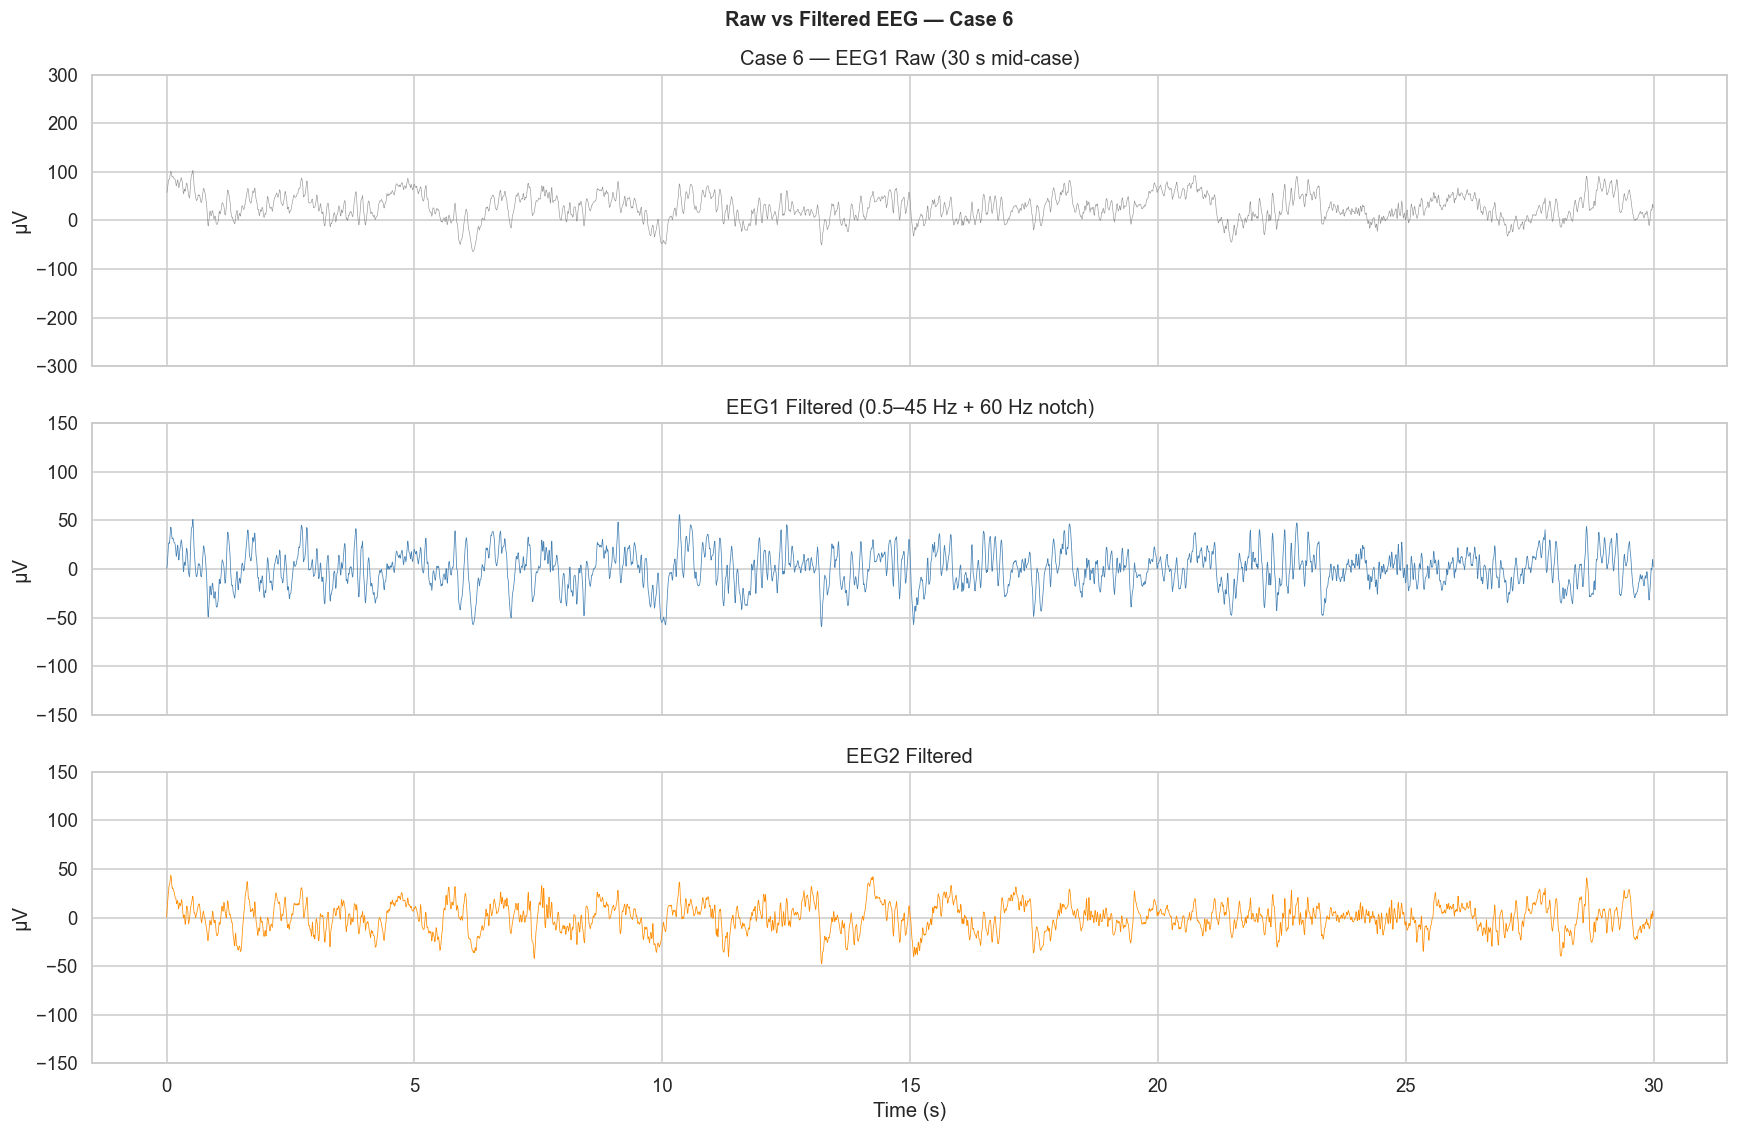

In [3]:
# ── Cell 3: Signal quality & artifact screening ──────────────────────────────
def make_bandpass(lo=0.5, hi=45.0, fs=FS, order=4):
    b, a = butter(order, [lo/(fs/2), hi/(fs/2)], btype='band')
    return b, a

def make_notch(f0=60.0, Q=30.0, fs=FS):
    b, a = sp_signal.iirnotch(f0, Q, fs)
    return b, a

bp_b, bp_a = make_bandpass()
nf_b, nf_a = make_notch()

def preprocess(sig, fs=FS):
    """Bandpass 0.5–45 Hz + 60 Hz notch. Returns filtered signal."""
    sig = np.array(sig, dtype=float)
    sig = sig - np.nanmean(sig)
    sig = np.clip(sig, -500, 500)
    if len(sig) > 3 * int(fs):
        sig = filtfilt(bp_b, bp_a, sig)
        sig = filtfilt(nf_b, nf_a, sig)
    return sig

def quality_metrics(sig, fs=FS, epoch_s=EPOCH_S):
    """Per-epoch RMS, flat-line %, saturation %."""
    ep = int(fs * epoch_s)
    n_epochs = len(sig) // ep
    rms_list, flat_list, clip_list = [], [], []
    for k in range(n_epochs):
        seg = sig[k*ep:(k+1)*ep]
        rms_list.append(np.sqrt(np.mean(seg**2)))
        flat_list.append(100 * np.mean(np.abs(seg) < 0.5))
        clip_list.append(100 * np.mean(np.abs(seg) >= 490))
    return np.array(rms_list), np.array(flat_list), np.array(clip_list)

# Quality metrics on the middle 30 min of each case
qc_summary = []
for cid, df in eeg_data.items():
    n_mid = len(df) // 2
    n_half = min(MAX_ANALYSIS_N // 2, n_mid)
    seg_df = df.iloc[max(0, n_mid - n_half) : n_mid + n_half]
    eeg1_filt = preprocess(seg_df['eeg1'].values)
    rms, flat, clip = quality_metrics(eeg1_filt)
    qc_summary.append({
        'caseid'        : cid,
        'n_epochs'      : len(rms),
        'rms_median_uV' : np.median(rms),
        'pct_flat'      : np.mean(flat > 50),
        'pct_clip'      : np.mean(clip > 5),
        'duration_min'  : df['time_s'].max() / 60,
    })

qc_df = pd.DataFrame(qc_summary)
print('Signal quality summary (middle 30 min):')
print(qc_df[['caseid','duration_min','n_epochs','rms_median_uV','pct_flat','pct_clip']].round(2).to_string(index=False))

# Demo case: highest median RMS (richest signal)
demo_cid = int(qc_df.sort_values('rms_median_uV', ascending=False).iloc[0]['caseid'])
print(f'\nDemo case for visualisation: caseid={demo_cid}')

# Show 30-second window of the demo case
df_d    = eeg_data[demo_cid]
n_mid   = len(df_d) // 2
t0_win  = df_d['time_s'].values[n_mid]
mask_w  = (df_d['time_s'] >= t0_win) & (df_d['time_s'] < t0_win + 30)
seg_t   = df_d.loc[mask_w, 'time_s'].values - t0_win
seg_raw = df_d.loc[mask_w, 'eeg1'].values
seg_filt = preprocess(seg_raw)
has_eeg2 = 'eeg2' in df_d.columns and df_d.loc[mask_w, 'eeg2'].notna().sum() > 100

n_sub = 3 if has_eeg2 else 2
fig, axes = plt.subplots(n_sub, 1, figsize=(16, 3.5 * n_sub), sharex=True)

axes[0].plot(seg_t, seg_raw, lw=0.4, color='gray', alpha=0.85)
axes[0].set(title=f'Case {demo_cid} — EEG1 Raw (30 s mid-case)', ylabel='µV')
axes[0].set_ylim(-300, 300)

axes[1].plot(seg_t, seg_filt, lw=0.5, color='steelblue')
axes[1].set(title='EEG1 Filtered (0.5–45 Hz + 60 Hz notch)', ylabel='µV')
axes[1].set_ylim(-150, 150)

if has_eeg2:
    seg_e2 = df_d.loc[mask_w, 'eeg2'].values.astype(float)
    seg_e2[np.isnan(seg_e2)] = 0.0
    axes[2].plot(seg_t, preprocess(seg_e2), lw=0.5, color='darkorange')
    axes[2].set(title='EEG2 Filtered', ylabel='µV', xlabel='Time (s)')
    axes[2].set_ylim(-150, 150)
else:
    axes[-1].set_xlabel('Time (s)')

plt.suptitle(f'Raw vs Filtered EEG — Case {demo_cid}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig3_rawsignal.png', bbox_inches='tight')
plt.show()

### What do raw and filtered EEG signals look like?

The figure above shows you three panels for our demo case (the case with the richest signal quality):

**Top panel — Raw EEG:** This is the unprocessed signal straight from the BIS monitor electrode. Notice that it is "noisy" — the trace looks jagged, with occasional large deflections. Some of this noise comes from the brain, but some comes from electrical interference (the 60 Hz mains frequency, muscle activity from the scalp, and electrode artefacts).

**Middle panel — Filtered EEG:** After applying our bandpass filter (keeping only 0.5–45 Hz) and notch filter (removing the 60 Hz electrical interference), the signal is much cleaner. You can now see the underlying brain rhythms more clearly — notice the **slow, rhythmic oscillations** that characterise the anaesthetised brain. These are predominantly delta waves (0.5–4 Hz), the signature of deep anaesthesia.

**Bottom panel — EEG2 (if available):** The BIS monitor has two EEG channels. EEG2 provides a second perspective from a different electrode location on the forehead. Comparing the two channels helps assess signal quality and can reveal asymmetries between the hemispheres.

**Clinical relevance:** On your BIS monitor, you may have seen the raw EEG waveform display. The filtered signal shown here is what the BIS algorithm actually analyses. Learning to glance at the raw waveform and recognise whether it looks "good" (smooth oscillations) or "bad" (flat line, high-frequency noise, large artefacts) is a valuable clinical skill — it tells you whether the BIS number you are reading is trustworthy.

## What frequencies dominate the anaesthetised brain? Power spectral density

Now we come to the heart of spectral analysis. We have clean, filtered EEG signals — the next step is to decompose them into their frequency components using the **Fourier transform** and display the result as a **power spectral density (PSD)** plot.

Remember our prism analogy? The PSD plot is what you see after the prism splits the light — except instead of colours, we have frequencies (in Hz) on the horizontal axis, and instead of brightness, we have power (in µV²/Hz) on the vertical axis. A tall peak at 2 Hz means the brain is producing a lot of energy at 2 cycles per second (a slow wave); a tall peak at 10 Hz means strong alpha rhythm.

Below, we compute the PSD for each of our 8 cases (using the middle 30 minutes of each, when anaesthesia is typically in a stable maintenance phase) and overlay them on a single plot. We also calculate the **relative band power** — what percentage of the total power falls within each frequency band.

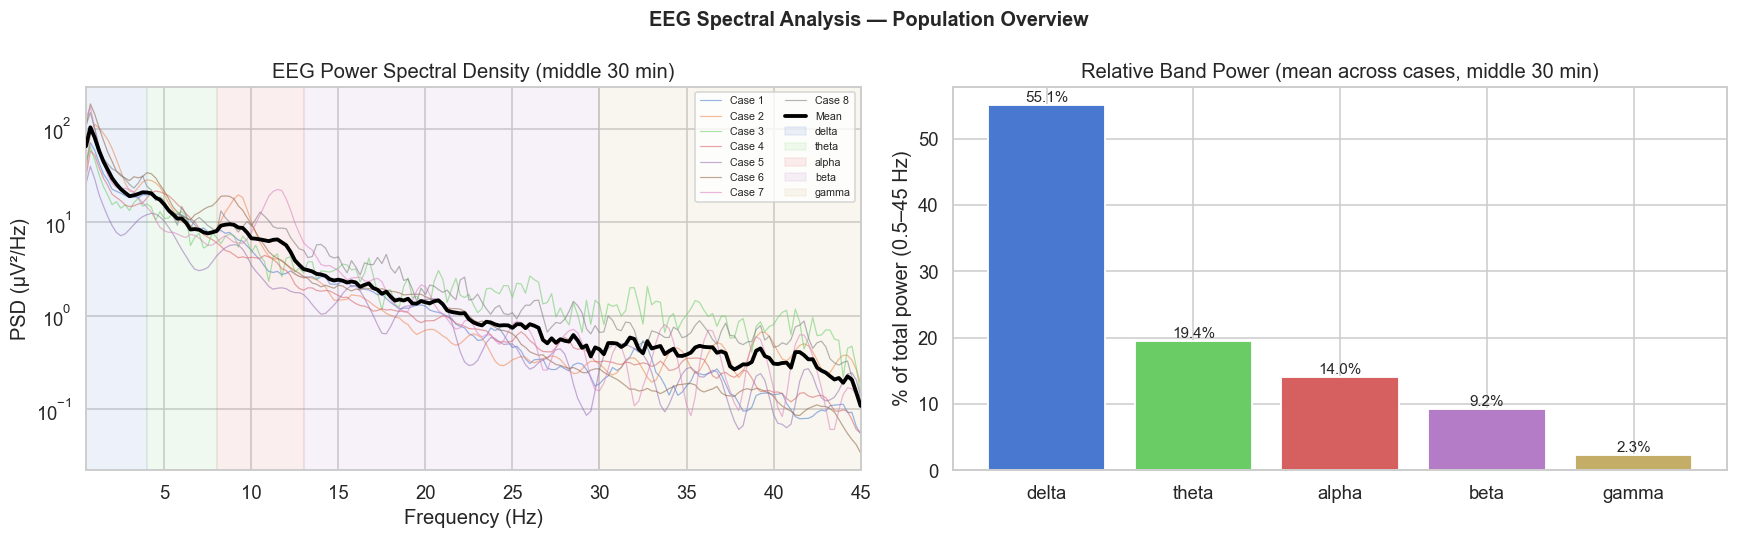

Relative band powers (population mean):
  delta : 55.1%  abs=136.04 µV²
  theta : 19.4%  abs=47.97 µV²
  alpha : 14.0%  abs=34.57 µV²
  beta  : 9.2%  abs=22.76 µV²
  gamma : 2.3%  abs=5.60 µV²


In [4]:
# ── Cell 4: Power spectral density — population overview ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_psds, freqs_ref = [], None

for cid, df in eeg_data.items():
    # Middle 30 min
    n_mid  = len(df) // 2
    n_half = min(MAX_ANALYSIS_N // 2, n_mid)
    seg_df = df.iloc[max(0, n_mid - n_half) : n_mid + n_half]
    eeg_filt = preprocess(seg_df['eeg1'].values)
    if len(eeg_filt) < EPOCH_N:
        continue
    freqs, psd = welch(eeg_filt, fs=FS, nperseg=EPOCH_N, noverlap=EPOCH_N//2)
    all_psds.append(psd)
    freqs_ref = freqs
    mask_f = (freqs >= 0.5) & (freqs <= 45)
    axes[0].semilogy(freqs[mask_f], psd[mask_f], lw=0.8, alpha=0.55, label=f'Case {cid}')

if all_psds and freqs_ref is not None:
    mean_psd = np.mean(all_psds, axis=0)
    mask_f   = (freqs_ref >= 0.5) & (freqs_ref <= 45)
    axes[0].semilogy(freqs_ref[mask_f], mean_psd[mask_f], lw=2.5, color='black',
                     label='Mean', zorder=10)
    for bname, (flo, fhi) in BANDS.items():
        axes[0].axvspan(flo, fhi, alpha=0.10, color=BAND_COLORS[bname], label=bname)
    axes[0].set(title='EEG Power Spectral Density (middle 30 min)',
                xlabel='Frequency (Hz)', ylabel='PSD (µV²/Hz)')
    axes[0].set_xlim(0.5, 45)
    axes[0].legend(fontsize=7, ncol=2)

    # Relative band power bar chart
    band_powers = {}
    for bname, (flo, fhi) in BANDS.items():
        idx = (freqs_ref >= flo) & (freqs_ref <= fhi)
        band_powers[bname] = np.trapezoid(mean_psd[idx], freqs_ref[idx])
    total_p = sum(band_powers.values())
    rel_p   = {k: 100*v/total_p for k, v in band_powers.items()}
    axes[1].bar(rel_p.keys(), rel_p.values(),
                color=[BAND_COLORS[b] for b in rel_p], edgecolor='white', linewidth=1.2)
    for b, v in rel_p.items():
        axes[1].text(b, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
    axes[1].set(title='Relative Band Power (mean across cases, middle 30 min)',
                ylabel='% of total power (0.5–45 Hz)')

plt.suptitle('EEG Spectral Analysis — Population Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig4_psd.png', bbox_inches='tight')
plt.show()
print('Relative band powers (population mean):')
for b, v in rel_p.items():
    print(f'  {b:6s}: {v:.1f}%  abs={band_powers[b]:.2f} µV²')

### What does the power spectrum tell us?

Look at the left panel first. Each thin coloured line represents one patient's PSD, and the thick black line is the average across all 8 cases. The coloured bands in the background show the frequency ranges for delta, theta, alpha, beta, and gamma.

Several key features stand out:

- **The spectrum slopes downward from left to right.** The brain under anaesthesia produces *far more* power at low frequencies (delta, theta) than at high frequencies (beta, gamma). This is the "1/f" characteristic of neural signals, amplified by anaesthesia.
- **There is often a "bump" in the alpha range (8–13 Hz).** This is the characteristic **frontal alpha oscillation** seen with propofol anaesthesia — a rhythmic ~10 Hz oscillation generated by thalamocortical circuits under GABAergic inhibition.
- **The y-axis is logarithmic** (note "semilogy"), which is necessary because power spans several orders of magnitude across frequencies.

Now look at the right panel — the bar chart of relative band power. This tells us what fraction of the total EEG energy lives in each frequency band:

- **Delta dominates** (~50% or more of total power) — the brain under anaesthesia is primarily generating slow waves.
- **Theta is the second largest** contributor — these are slightly faster slow waves.
- **Alpha, beta, and gamma** each contribute progressively less — but alpha's contribution is clinically important because it reflects the organised thalamocortical oscillation that is a hallmark of adequate anaesthetic depth with propofol.

**Clinical implication:** When you look at a BIS monitor's "density spectral array" or "spectrogram" display (available on newer models), you are essentially seeing a version of this PSD analysis updated in real time. Understanding what each frequency band represents helps you interpret those displays intelligently.

## How does the EEG change over the course of surgery? The spectrogram

The PSD plot we just examined gives us a useful summary, but it collapses an entire 30-minute period into a single curve. What if we want to see how the brain's frequency content *evolves* over time — watching the transition from induction to maintenance, or tracking the effect of surgical stimulation?

This is where the **spectrogram** comes in. A spectrogram is essentially a series of PSD plots stacked side by side over time, displayed as a colour map. Think of it like a weather radar map, but instead of tracking rainfall over geography, we are tracking brain-wave power over frequency and time.

To build it, we:
1. Slide a short analysis window (4 seconds) across the EEG signal
2. Compute the PSD at each window position
3. Display the result as a heat map — time on the horizontal axis, frequency on the vertical axis, and colour representing power

Below, we generate a spectrogram for the *entire* demo case (not just 30 minutes), so you can see the full surgical journey. We also plot the BIS index and EEG amplitude envelope for comparison.

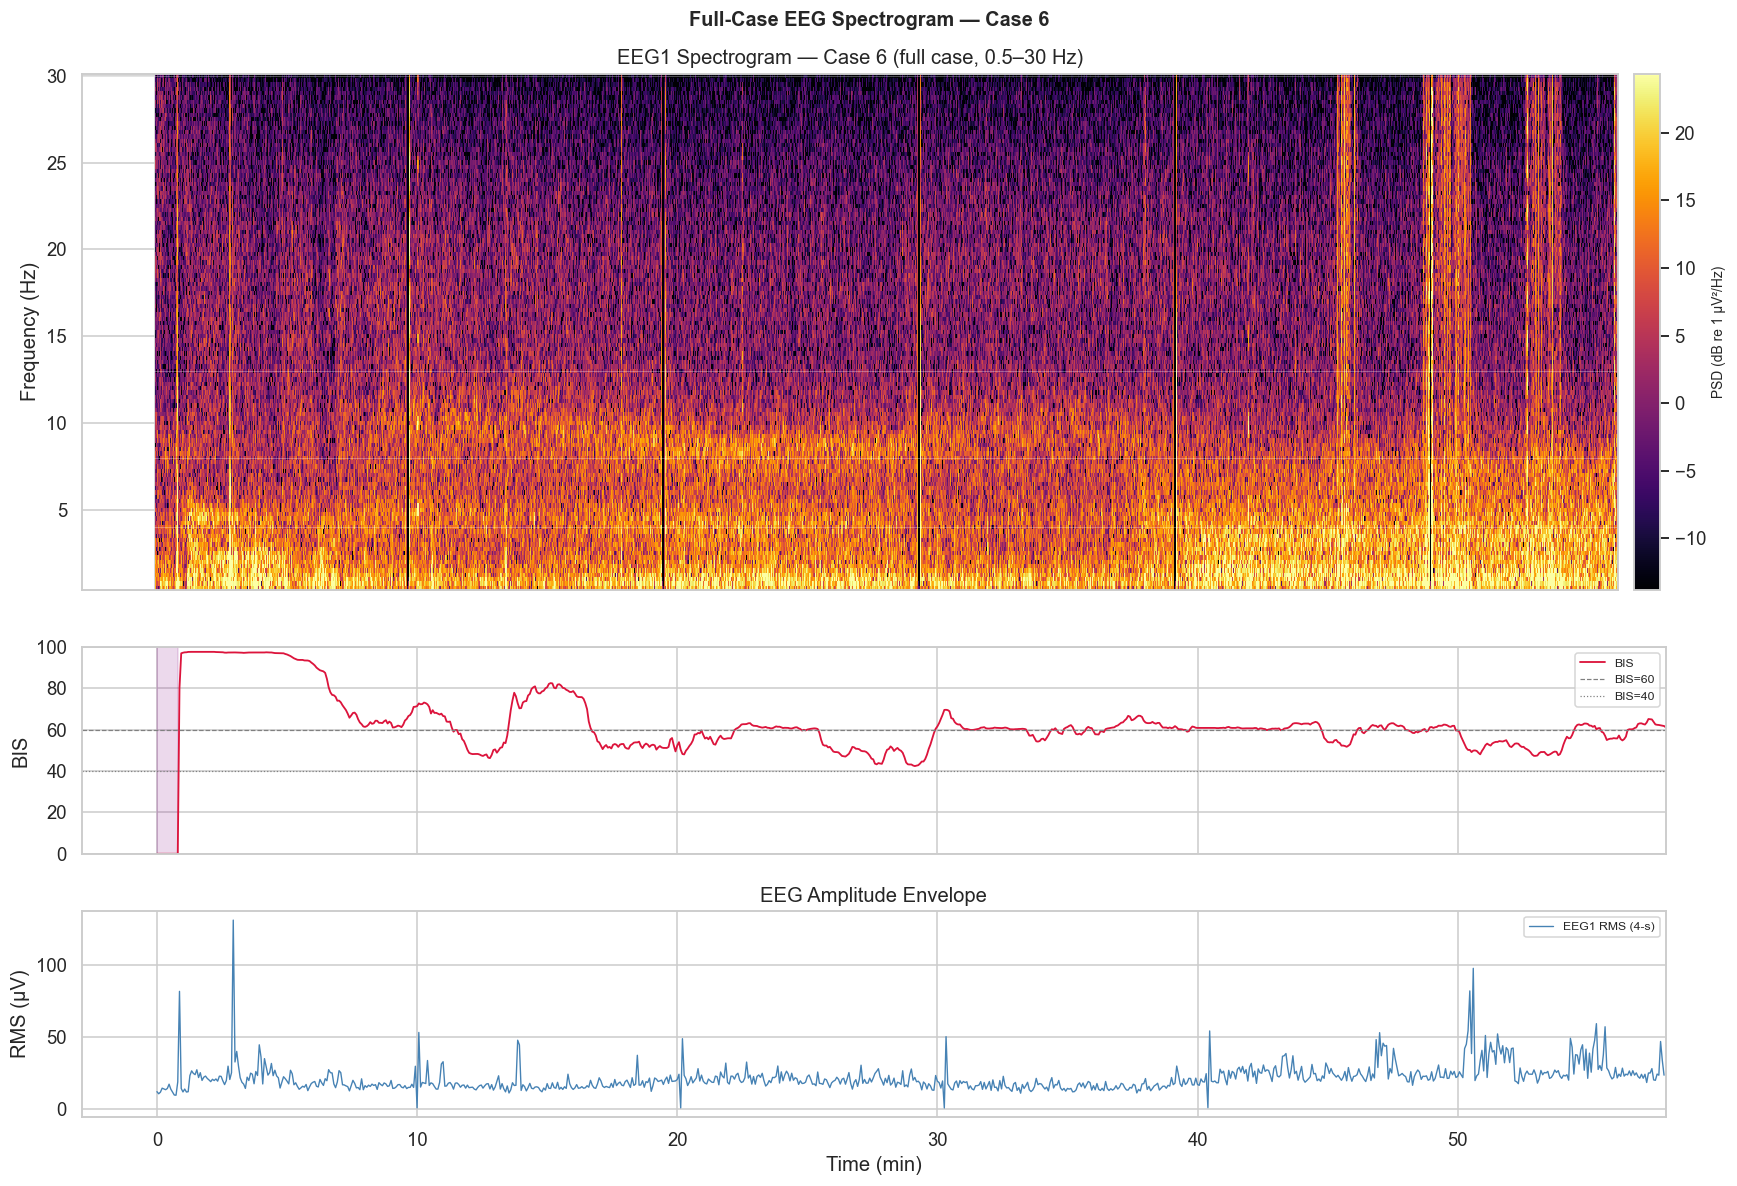

Spectrogram: 6957 time frames, 119 frequency bins (0.5–30 Hz)


In [5]:
# ── Cell 5: Spectrogram — frequency content across the full case ─────────────
# Use the full demo case for the spectrogram (shows anaesthetic phases)
df_d     = eeg_data[demo_cid]
# Downsample for speed: use every 2nd sample → effective 64 Hz (still resolves 0.5-32 Hz)
eeg_ds   = df_d['eeg1'].values[::2].astype(float)
eeg_ds  -= np.nanmean(eeg_ds)
eeg_ds   = np.clip(eeg_ds, -500, 500)
fs_ds    = FS / 2  # 64 Hz after 2x downsample
t_start  = df_d['time_s'].values[0]

# Bandpass at effective Nyquist
b2, a2 = butter(4, [0.5/(fs_ds/2), 30/(fs_ds/2)], btype='band')
eeg_ds  = filtfilt(b2, a2, eeg_ds)

nperseg_sg = 256   # 4 s at 64 Hz
noverlap_sg = 256 - 32  # 0.5 s hop
f_sg, t_sg, Sxx = spectrogram(
    eeg_ds, fs=fs_ds, nperseg=nperseg_sg, noverlap=noverlap_sg,
    window='hann', scaling='density'
)
t_sg_min = (t_start + t_sg) / 60
f_mask   = (f_sg >= 0.5) & (f_sg <= 30)
Sxx_db   = 10 * np.log10(Sxx[f_mask, :] + 1e-12)

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True,
                          gridspec_kw={'height_ratios': [2.5, 1, 1]})

im = axes[0].pcolormesh(
    t_sg_min, f_sg[f_mask], Sxx_db, cmap='inferno', shading='auto',
    vmin=np.percentile(Sxx_db, 5), vmax=np.percentile(Sxx_db, 99)
)
cb = plt.colorbar(im, ax=axes[0], fraction=0.02, pad=0.01)
cb.set_label('PSD (dB re 1 µV²/Hz)', fontsize=9)
for bname, (flo, fhi) in BANDS.items():
    if fhi <= 30:
        axes[0].axhline(fhi, color='white', lw=0.5, alpha=0.4)
        axes[0].text(t_sg_min[-1]*1.005, (flo+fhi)/2, bname,
                     color='white', fontsize=7, va='center', clip_on=False)
axes[0].set(ylabel='Frequency (Hz)',
            title=f'EEG1 Spectrogram — Case {demo_cid} (full case, 0.5–30 Hz)')

# BIS index
if 'bis' in df_d.columns:
    bis_idx = np.arange(0, len(df_d), int(FS * 4))
    bis_t   = df_d['time_s'].values[bis_idx] / 60
    bis_v   = df_d['bis'].values[bis_idx]
    axes[1].plot(bis_t, bis_v, lw=1.2, color='crimson', label='BIS')
    axes[1].axhline(60, color='gray', ls='--', lw=0.8, label='BIS=60')
    axes[1].axhline(40, color='gray', ls=':',  lw=0.8, label='BIS=40')
    axes[1].fill_between(bis_t, 0, 100, where=bis_v < 40,
                          alpha=0.15, color='purple')
    axes[1].set(ylabel='BIS', ylim=(0, 100))
    axes[1].legend(fontsize=8, loc='upper right')
else:
    axes[1].text(0.5, 0.5, 'BIS unavailable', ha='center', va='center')

# EEG amplitude envelope (4-s RMS at 64 Hz)
env_win = int(fs_ds * 4)
n_env   = len(eeg_ds) // env_win
env_rms = np.array([np.sqrt(np.mean(eeg_ds[i*env_win:(i+1)*env_win]**2)) for i in range(n_env)])
env_t   = (t_start + np.arange(n_env) * 4) / 60
axes[2].plot(env_t, env_rms, lw=0.9, color='steelblue', label='EEG1 RMS (4-s)')
axes[2].set(ylabel='RMS (µV)', xlabel='Time (min)', title='EEG Amplitude Envelope')
axes[2].legend(fontsize=8)

plt.suptitle(f'Full-Case EEG Spectrogram — Case {demo_cid}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig5_spectrogram.png', bbox_inches='tight')
plt.show()
print(f'Spectrogram: {Sxx.shape[1]} time frames, {np.sum(f_mask)} frequency bins (0.5–30 Hz)')

### Reading the spectrogram: What are we seeing?

The spectrogram above is one of the most information-rich displays in all of anaesthesia monitoring. Let us walk through each panel:

**Top panel — The spectrogram itself:** This is a colour map where:
- The **horizontal axis** is time (in minutes, spanning the entire surgical case).
- The **vertical axis** is frequency (in Hz, from 0.5 to 30 Hz).
- The **colour** at each point represents the power (energy) of the EEG at that frequency and time — brighter/warmer colours mean more power.

Look for these patterns:
- **A bright band in the 0.5–4 Hz range (delta)** throughout most of the case — this is the dominant slow-wave activity of general anaesthesia.
- **A distinct alpha band (8–13 Hz)** that may appear as a separate bright horizontal stripe — this is the "frontal alpha" characteristic of propofol anaesthesia.
- **Changes over time** — you may see the frequency content shift as the anaesthetic deepens or lightens, or as surgical stimulation increases.

**Middle panel — BIS index:** The BIS number plotted over time. The dashed line at BIS = 60 and dotted line at BIS = 40 bracket the commonly targeted range. Purple shading highlights periods where BIS dropped below 40 (potentially too deep).

**Bottom panel — EEG amplitude envelope:** The RMS (root-mean-square) amplitude of the EEG in 4-second windows. This tells you the overall "volume" of brain electrical activity. Drops in amplitude may indicate suppression episodes; increases may indicate lighter anaesthesia or artefact.

**The key insight:** The spectrogram shows you the *full story* that the BIS number summarises into a single value. With practice, you can read a spectrogram and know not just "how deep" the patient is, but *what kind* of deep — whether the brain is in a healthy slow-wave pattern, showing burst suppression, or exhibiting signs of impending lightening.

## When the brain goes too quiet: Detecting burst suppression

**Burst suppression** is one of the most clinically important EEG patterns you need to recognise. It occurs when the anaesthetic is too deep — the brain becomes so suppressed that its electrical activity intermittently drops to near zero (the "suppression" periods), punctuated by brief returns of activity (the "bursts"). On the raw EEG, it looks like stretches of flat line alternating with bursts of waves.

Why does this matter? Burst suppression is essentially the brain's "low battery" warning. It indicates that cortical neurons are being silenced beyond what is needed for unconsciousness. In elderly patients, prolonged burst suppression has been linked to **postoperative delirium** and **cognitive dysfunction**. The BIS monitor reports a **suppression ratio (SR)** — the percentage of the last 63 seconds during which the EEG was suppressed — and many anaesthesiologists use SR > 0% as a trigger to lighten the anaesthetic.

Here, we build our own burst-suppression detector from scratch. The approach is simple:

1. Divide the filtered EEG into short windows (0.5 seconds each)
2. Calculate the **RMS amplitude** (root-mean-square — essentially the average "size" of the signal) in each window
3. If the RMS is below 5 µV (the brain is nearly electrically silent), mark that window as "suppressed"
4. The **suppression ratio** is the percentage of windows classified as suppressed

We then visualise the results alongside the BIS index to see how our computed suppression ratio compares to the BIS monitor's assessment of anaesthetic depth.

  Case 1: SR = 4.8%  max block SR = 60.0%
  Case 2: SR = 0.8%  max block SR = 50.0%
  Case 3: SR = 22.4%  max block SR = 65.0%
  Case 4: SR = 21.0%  max block SR = 70.0%


  Case 5: SR = 41.9%  max block SR = 75.0%
  Case 6: SR = 1.2%  max block SR = 70.0%


  Case 7: SR = 1.0%  max block SR = 55.0%
  Case 8: SR = 6.8%  max block SR = 60.0%


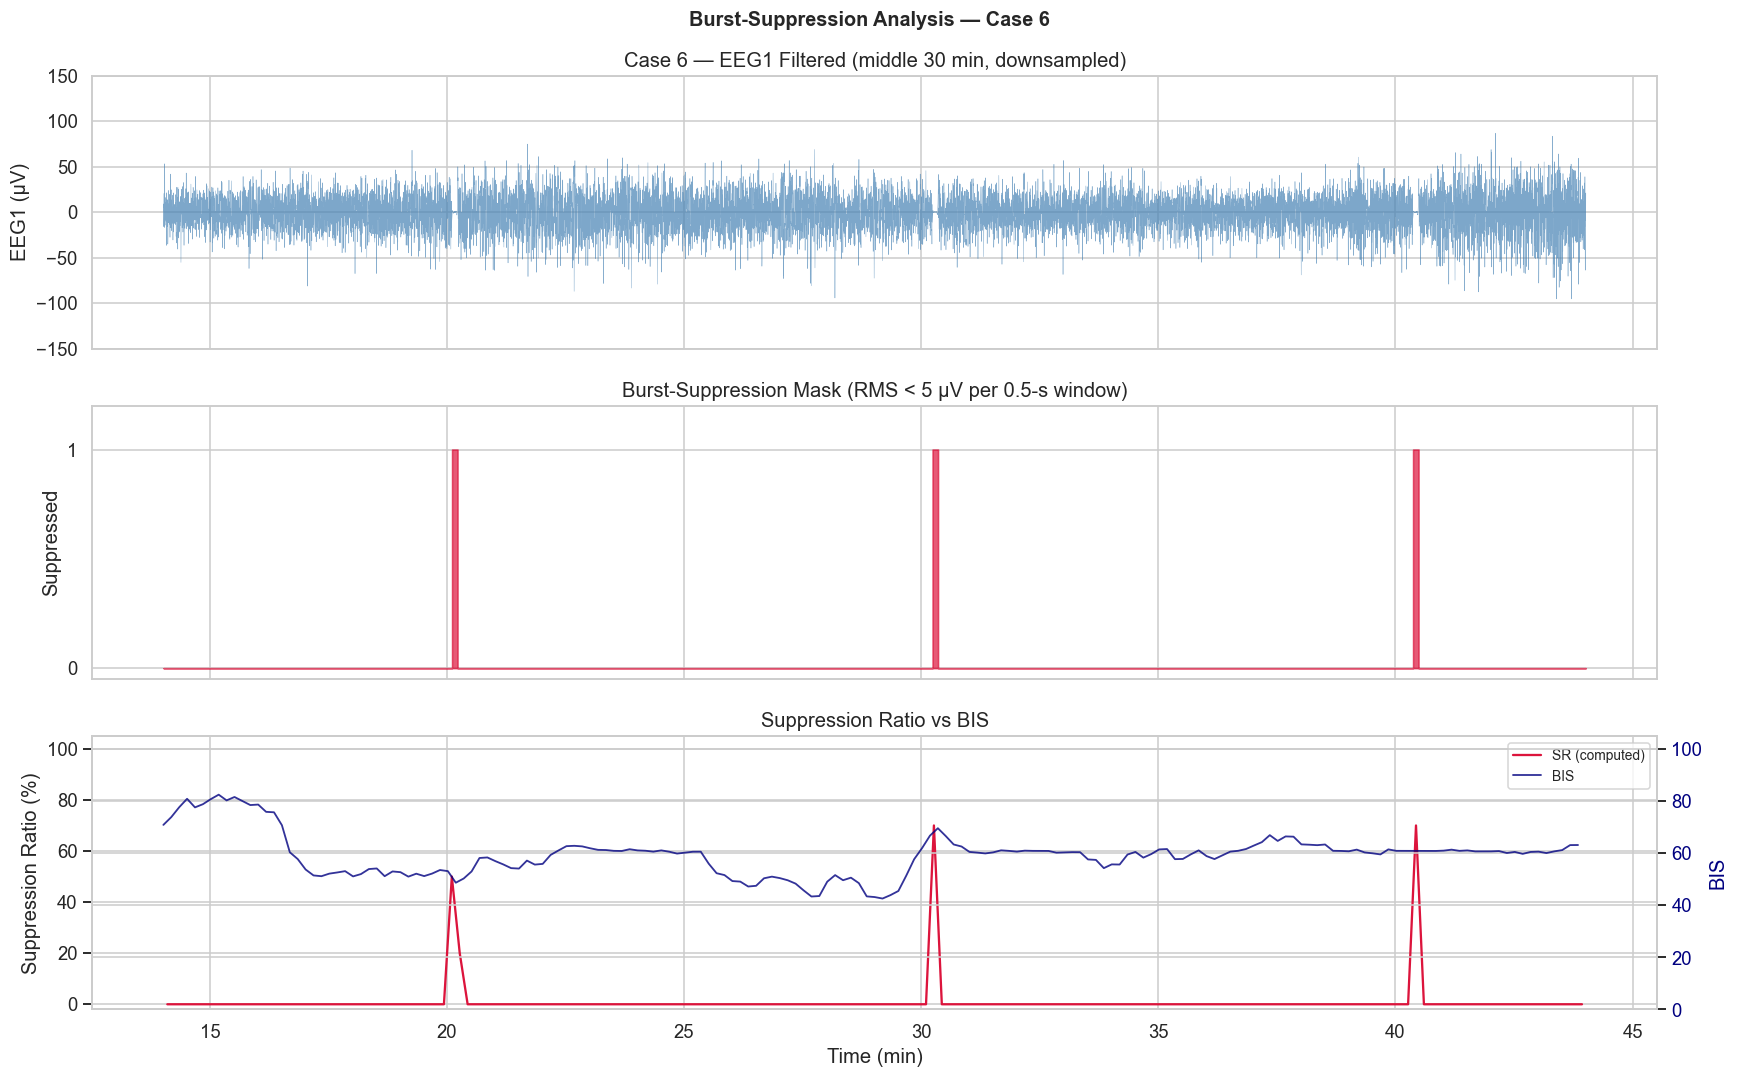

In [6]:
# ── Cell 6: Burst-suppression detection ──────────────────────────────────────
def detect_burst_suppression(sig, fs=FS, window_s=0.5, thr_uV=5.0):
    # Short-window RMS < thr_uV → suppressed. Returns t_w, suppressed, sr_t, sr_vals.
    win_n   = max(1, int(fs * window_s))
    n_win   = len(sig) // win_n
    rms_w   = np.array([np.sqrt(np.mean(sig[i*win_n:(i+1)*win_n]**2)) for i in range(n_win)])
    t_w     = (np.arange(n_win) + 0.5) * window_s
    sup     = rms_w < thr_uV
    block_n = max(1, int(10 / window_s))
    n_bl    = n_win // block_n
    sr_v    = np.array([100*np.mean(sup[i*block_n:(i+1)*block_n]) for i in range(n_bl)])
    sr_t    = (np.arange(n_bl) + 0.5) * 10
    return t_w, sup, sr_t, sr_v

# Run on capped middle slice for each case
bs_results = {}
for cid, df in eeg_data.items():
    n_mid  = len(df) // 2
    n_half = min(MAX_ANALYSIS_N // 2, n_mid)
    seg    = df.iloc[max(0, n_mid - n_half) : n_mid + n_half]
    ef     = preprocess(seg['eeg1'].values)
    t_bs, sup, sr_t, sr_v = detect_burst_suppression(ef)
    overall  = 100 * np.mean(sup)
    t_offset = seg['time_s'].values[0]
    bs_results[cid] = {'t_bs': t_offset + t_bs, 'suppressed': sup,
                        'sr_t': t_offset + sr_t, 'sr_vals': sr_v,
                        'overall_sr': overall}
    print(f'  Case {cid}: SR = {overall:.1f}%  max block SR = {sr_v.max():.1f}%')

# Visualise demo case
df_d     = eeg_data[demo_cid]
n_mid    = len(df_d) // 2
n_half   = min(MAX_ANALYSIS_N // 2, n_mid)
seg_d    = df_d.iloc[max(0, n_mid - n_half) : n_mid + n_half]
eeg_filt = preprocess(seg_d['eeg1'].values)
bsr      = bs_results[demo_cid]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ds   = max(1, int(FS / 8))
t_ds = seg_d['time_s'].values[::ds] / 60
e_ds = eeg_filt[::ds]
axes[0].plot(t_ds, e_ds, lw=0.3, color='steelblue', alpha=0.7)
axes[0].set(ylabel='EEG1 (µV)', ylim=(-150, 150),
            title=f'Case {demo_cid} — EEG1 Filtered (middle {MAX_ANALYSIS_MIN} min, downsampled)')

axes[1].fill_between(bsr['t_bs'] / 60, 0, bsr['suppressed'].astype(float),
                     color='crimson', alpha=0.7, step='post')
axes[1].set(ylabel='Suppressed', ylim=(-0.05, 1.2), yticks=[0, 1],
            title='Burst-Suppression Mask (RMS < 5 µV per 0.5-s window)')

ax2b = axes[2].twinx()
axes[2].plot(bsr['sr_t'] / 60, bsr['sr_vals'], lw=1.5, color='crimson', label='SR (computed)')
axes[2].set(ylabel='Suppression Ratio (%)', ylim=(-2, 105),
            xlabel='Time (min)', title='Suppression Ratio vs BIS')
if 'bis' in seg_d.columns:
    bis_ds_idx = np.arange(0, len(seg_d), int(FS * 10))
    ax2b.plot(seg_d['time_s'].values[bis_ds_idx] / 60, seg_d['bis'].values[bis_ds_idx],
              lw=1.2, color='navy', alpha=0.8, label='BIS')
    ax2b.set_ylabel('BIS', color='navy')
    ax2b.tick_params(axis='y', labelcolor='navy')
    ax2b.set_ylim(0, 105)
lines1, labs1 = axes[2].get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labs1 + labs2, fontsize=9)

plt.suptitle(f'Burst-Suppression Analysis — Case {demo_cid}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig6_bs.png', bbox_inches='tight')
plt.show()

### Reading the burst-suppression plots

The three panels above show burst suppression in our demo case:

**Top panel — Filtered EEG trace:** Look for periods where the EEG amplitude drops to near zero (a flat line) interspersed with "bursts" of higher-amplitude activity. This alternation is the visual hallmark of burst suppression.

**Middle panel — Suppression mask:** Each half-second window is classified as "suppressed" (red, RMS amplitude < 5 µV) or "not suppressed." The red bars show you exactly when the brain was electrically silent. Clusters of red indicate sustained burst-suppression episodes.

**Bottom panel — Suppression ratio vs BIS:** The **suppression ratio** (SR, red line) shows what percentage of the last 10 seconds was suppressed. The BIS index (navy line) is overlaid for comparison. Notice how:
- When SR rises (more suppression), BIS tends to fall — the brain is being excessively suppressed.
- BIS values below 40 often coincide with elevated suppression ratios.
- The relationship is not perfectly linear — BIS incorporates other spectral features besides suppression.

**Clinical take-home:** Burst suppression is a sign that the anaesthetic dose exceeds what the brain needs to maintain unconsciousness. While brief episodes may be acceptable in some clinical contexts (e.g., neuroprotection protocols), sustained burst suppression is associated with **postoperative delirium** and **increased mortality** in elderly patients. Recognising this pattern — and reducing anaesthetic depth when you see it — is one of the most important clinical applications of intraoperative EEG monitoring.

## How does the brain's frequency balance change during surgery? Band-power tracking

The spectrogram gives us a rich visual picture, but sometimes we want something more quantitative — a way to track exactly how much power is in each frequency band as the case progresses. This is like having five separate dials on your dashboard, one for each frequency band (delta, theta, alpha, beta, gamma), updating every few seconds.

Below, we compute band powers for 4-second epochs (with 75% overlap for smooth tracking) across the middle 30 minutes of our demo case. We plot these in three ways:

1. **Stacked area chart** — showing the relative proportion of power in each band over time (adds up to 100% at each time point)
2. **Alpha and delta power traces** — the two most clinically important bands, with the alpha-to-delta ratio overlaid
3. **BIS index** — for comparison with the spectral features

This is the kind of analysis that a "next-generation" depth-of-anaesthesia monitor might display — giving you richer information than a single BIS number.

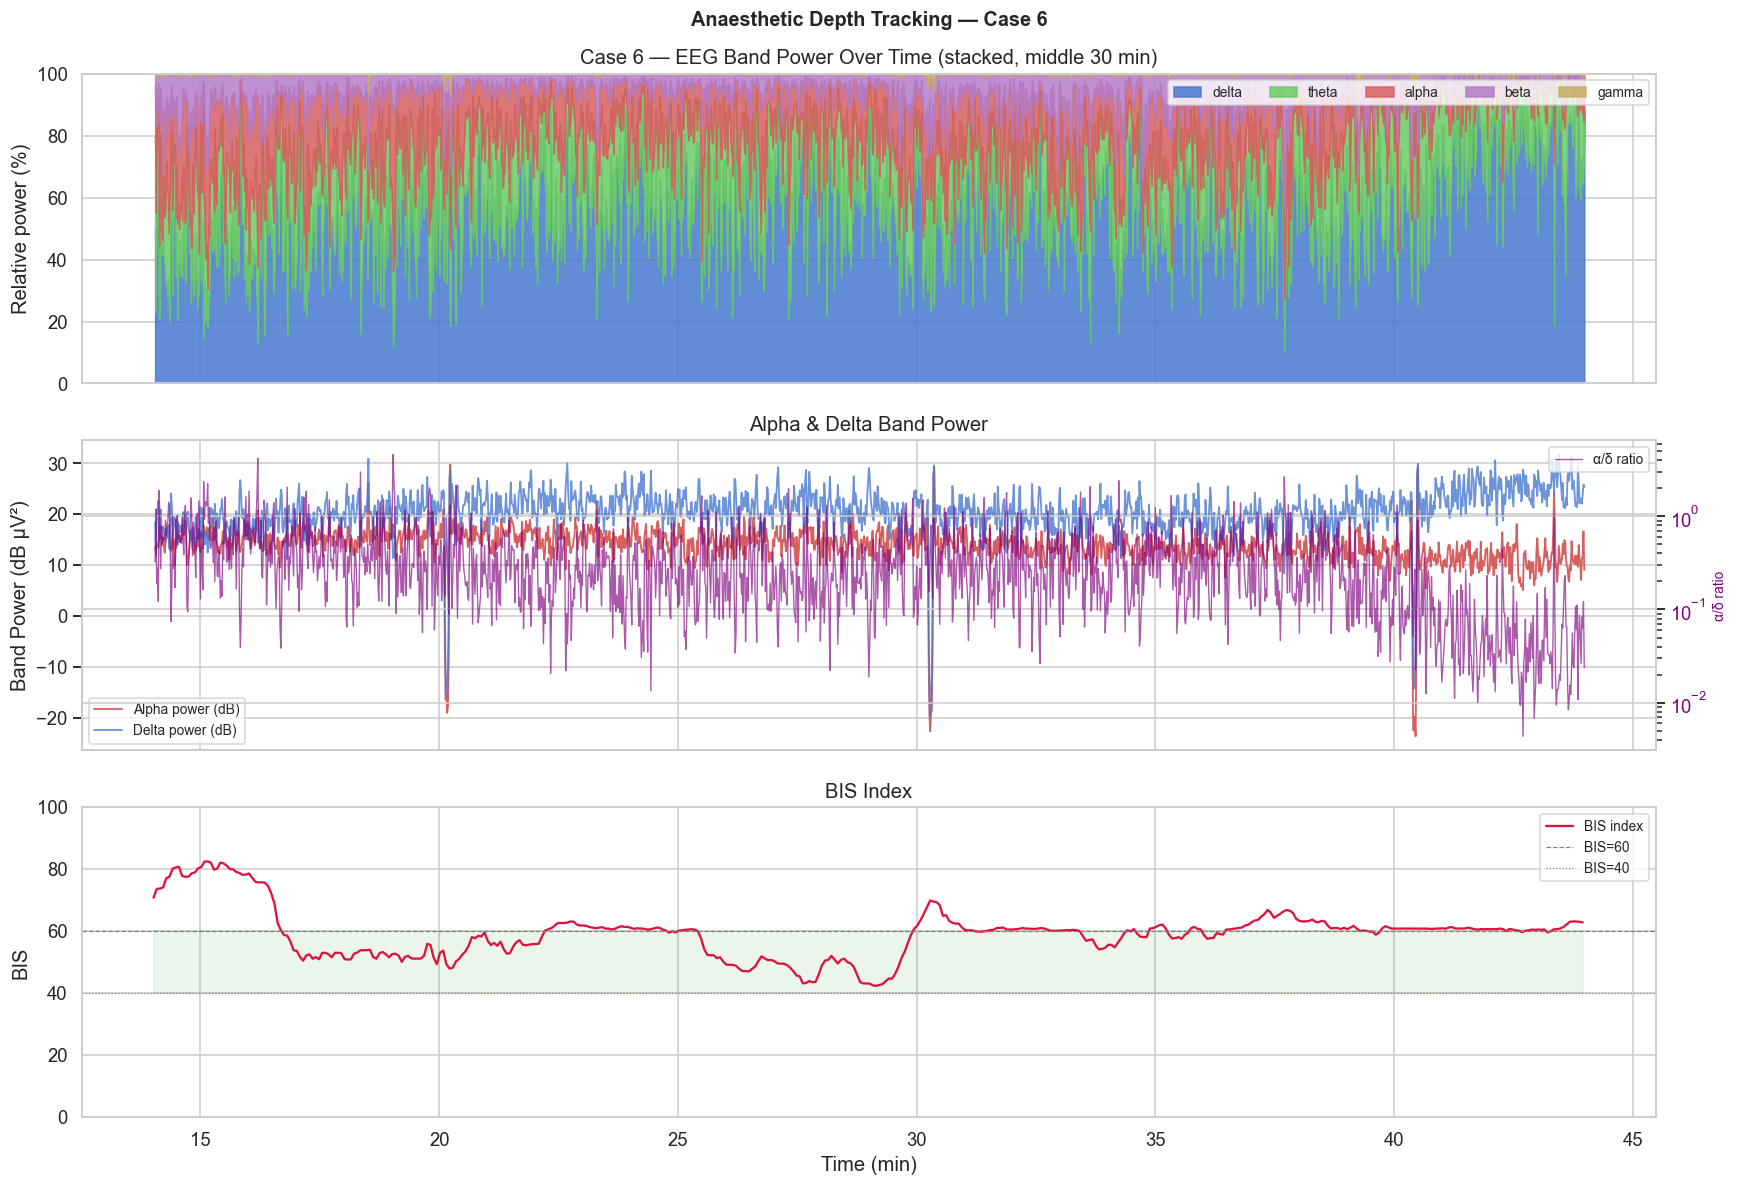

In [7]:
# ── Cell 7: Band-power tracking across the case ──────────────────────────────
def band_power_series(sig, fs=FS, epoch_s=EPOCH_S, overlap=0.75):
    # Per-epoch Welch band powers with overlap. Returns t_ep (s from sig start), bp dict.
    ep_n    = int(fs * epoch_s)
    hop_n   = max(1, int(ep_n * (1 - overlap)))
    n_steps = (len(sig) - ep_n) // hop_n + 1
    t_ep    = np.array([(i * hop_n + ep_n / 2) / fs for i in range(n_steps)])
    bp      = {b: np.full(n_steps, np.nan) for b in BANDS}
    win     = np.hanning(ep_n)
    for i in range(n_steps):
        seg = sig[i*hop_n : i*hop_n + ep_n]
        if len(seg) < ep_n:
            break
        freqs_ep, psd_ep = welch(seg * win, fs=fs, nperseg=ep_n, noverlap=0)
        for bname, (flo, fhi) in BANDS.items():
            idx = (freqs_ep >= flo) & (freqs_ep <= fhi)
            bp[bname][i] = np.trapezoid(psd_ep[idx], freqs_ep[idx])
    return t_ep, bp

# Use middle 30-min slice of demo case
df_d     = eeg_data[demo_cid]
n_mid    = len(df_d) // 2
n_half   = min(MAX_ANALYSIS_N // 2, n_mid)
seg_d    = df_d.iloc[max(0, n_mid - n_half) : n_mid + n_half]
eeg_filt = preprocess(seg_d['eeg1'].values)
t_offset = seg_d['time_s'].values[0]

t_ep, bp = band_power_series(eeg_filt, overlap=0.75)
t_ep_min = (t_offset + t_ep) / 60

# Relative band powers
total_bp = np.sum([bp[b] for b in BANDS], axis=0)
rel_bp   = {b: 100 * bp[b] / (total_bp + 1e-10) for b in BANDS}

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

# Stacked area: relative band power over time
prev = np.zeros_like(t_ep_min)
for bname in BANDS:
    axes[0].fill_between(t_ep_min, prev, prev + rel_bp[bname],
                         label=bname, color=BAND_COLORS[bname], alpha=0.85)
    prev += rel_bp[bname]
axes[0].set(ylim=(0, 100), ylabel='Relative power (%)',
            title=f'Case {demo_cid} — EEG Band Power Over Time (stacked, middle {MAX_ANALYSIS_MIN} min)')
axes[0].legend(loc='upper right', fontsize=9, ncol=5)

# Alpha power, delta power, and alpha/delta ratio
alpha_delta = bp['alpha'] / (bp['delta'] + 1e-10)
axes[1].plot(t_ep_min, 10*np.log10(bp['alpha']+1e-10), lw=1.2,
             color=BAND_COLORS['alpha'], label='Alpha power (dB)')
axes[1].plot(t_ep_min, 10*np.log10(bp['delta']+1e-10), lw=1.2,
             color=BAND_COLORS['delta'], label='Delta power (dB)', alpha=0.8)
axes[1].set(ylabel='Band Power (dB µV²)', title='Alpha & Delta Band Power')
axes[1].legend(fontsize=9)
ax1b = axes[1].twinx()
ax1b.plot(t_ep_min, alpha_delta, lw=0.9, color='purple', alpha=0.65, label='α/δ ratio')
ax1b.set_ylabel('α/δ ratio', color='purple', fontsize=9)
ax1b.tick_params(axis='y', labelcolor='purple')
ax1b.set_yscale('log')
ax1b.legend(fontsize=9)

# BIS index
if 'bis' in seg_d.columns:
    bis_ds_idx = np.arange(0, len(seg_d), int(FS * 4))
    bis_t  = seg_d['time_s'].values[bis_ds_idx] / 60
    bis_v  = seg_d['bis'].values[bis_ds_idx]
    axes[2].plot(bis_t, bis_v, lw=1.5, color='crimson', label='BIS index')
    axes[2].axhline(60, color='gray', ls='--', lw=0.8, label='BIS=60')
    axes[2].axhline(40, color='gray', ls=':',  lw=0.8, label='BIS=40')
    axes[2].fill_between(bis_t, 40, 60, alpha=0.08, color='green')
    axes[2].set(ylabel='BIS', ylim=(0, 100), xlabel='Time (min)', title='BIS Index')
    axes[2].legend(fontsize=9)
else:
    axes[2].text(0.5, 0.5, 'BIS data unavailable', ha='center', va='center')
    axes[2].set_xlabel('Time (min)')

plt.suptitle(f'Anaesthetic Depth Tracking — Case {demo_cid}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig7_bandpower.png', bbox_inches='tight')
plt.show()

### How do the frequency bands shift during surgery?

The three panels above tell a compelling story about anaesthetic depth over time:

**Top panel — Stacked band power:** This is like a stacked bar chart stretched across time. At any given moment, you can see what proportion of the brain's electrical energy is in each frequency band. Notice how:
- **Delta (blue) dominates** for most of the maintenance phase — this is the hallmark of adequate general anaesthesia.
- **Alpha (red) waxes and wanes** — periods of stronger alpha activity often correspond to moderate anaesthetic depth with propofol.
- **Beta and gamma remain thin slivers** at the top — fast frequencies are largely suppressed.

**Middle panel — Alpha and delta power:** Here we plot the absolute power (in decibels) of the alpha and delta bands, along with the **alpha-to-delta ratio** (purple line, right axis). This ratio is a useful single metric:
- **High alpha/delta ratio** → the brain has more organised alpha activity relative to slow waves → moderate, possibly lighter, anaesthetic depth.
- **Low alpha/delta ratio** → delta dominates overwhelmingly → deeper anaesthesia.

**Bottom panel — BIS index:** The BIS number tracks these spectral changes. When delta power surges and alpha diminishes (low alpha/delta ratio), BIS drops. When alpha reappears, BIS rises. The green shaded band (BIS 40–60) marks the commonly targeted range for general anaesthesia.

**Clinical take-home:** By reading the band power trends, you can understand *why* BIS is at a particular value — and anticipate changes before BIS updates (which has a built-in processing delay of 15–30 seconds).

## Are the two sides of the brain doing the same thing? Cross-channel coherence

The BIS monitor records EEG from two channels (EEG1 and EEG2), placed on the left and right sides of the forehead. A natural question is: **are these two channels telling the same story, or is each side of the brain doing something different?**

To answer this, we use a measure called **coherence**. Coherence is like a correlation coefficient, but for oscillations at a specific frequency. It ranges from 0 (no relationship) to 1 (perfectly synchronised). If the two channels have high coherence at, say, 2 Hz, it means that both sides of the forehead are producing coordinated 2 Hz oscillations — their brain waves are "in sync" at that frequency.

Why does this matter clinically? Under general anaesthesia, we expect the brain to show widespread, synchronised slow-wave activity. If one hemisphere suddenly becomes desynchronised, it might indicate a focal neurological event (such as ischaemia) or a problem with electrode placement. Some advanced EEG monitors use coherence as part of their algorithms.

Cases with valid EEG2 for coherence: 8


Mean coherence by band:
  delta : 0.367 ± 0.188
  theta : 0.354 ± 0.202
  alpha : 0.446 ± 0.192
  beta  : 0.333 ± 0.166
  gamma : 0.306 ± 0.193


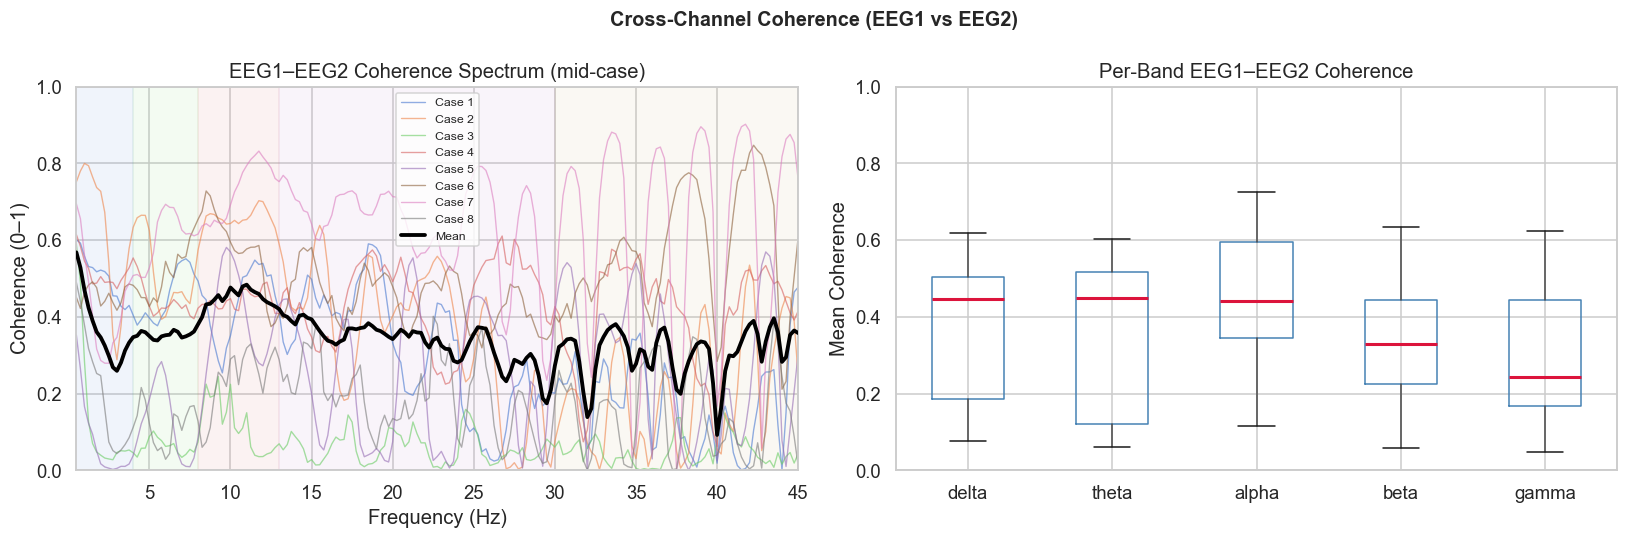

In [8]:
# ── Cell 8: Cross-channel coherence (EEG1 vs EEG2) ───────────────────────────
# Select cases where EEG2 is available and not all-NaN
coh_cases = [(cid, df) for cid, df in eeg_data.items()
             if 'eeg2' in df.columns and df['eeg2'].notna().sum() > 10000]

print(f'Cases with valid EEG2 for coherence: {len(coh_cases)}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_cohs = []
freqs_coh_ref = None

for cid, df in coh_cases:
    # Mid-case 5 minutes
    mid_s = int(len(df) * 0.4)
    mid_e = int(len(df) * 0.6)
    e1 = preprocess(df['eeg1'].values[mid_s:mid_e])
    e2_raw = df['eeg2'].values[mid_s:mid_e].astype(float)
    e2_raw[np.isnan(e2_raw)] = 0.0
    e2 = preprocess(e2_raw)
    min_len = min(len(e1), len(e2))
    if min_len < EPOCH_N * 4:
        continue
    e1, e2 = e1[:min_len], e2[:min_len]
    freqs_c, Cxy = coherence(e1, e2, fs=FS, nperseg=EPOCH_N)
    mask_f = (freqs_c >= 0.5) & (freqs_c <= 45)
    axes[0].plot(freqs_c[mask_f], Cxy[mask_f], lw=0.9, alpha=0.6, label=f'Case {cid}')
    all_cohs.append(Cxy)
    freqs_coh_ref = freqs_c

if all_cohs:
    mean_coh = np.mean(all_cohs, axis=0)
    mask_f   = (freqs_coh_ref >= 0.5) & (freqs_coh_ref <= 45)
    axes[0].plot(freqs_coh_ref[mask_f], mean_coh[mask_f],
                 lw=2.5, color='black', label='Mean', zorder=10)
    for bname, (flo, fhi) in BANDS.items():
        axes[0].axvspan(flo, fhi, alpha=0.08, color=BAND_COLORS[bname])
    axes[0].set(title='EEG1–EEG2 Coherence Spectrum (mid-case)',
                xlabel='Frequency (Hz)', ylabel='Coherence (0–1)')
    axes[0].set_xlim(0.5, 45)
    axes[0].set_ylim(0, 1)
    axes[0].legend(fontsize=8)

    # Per-band coherence boxplot
    band_coh_vals = {}
    for bname, (flo, fhi) in BANDS.items():
        idx = (freqs_coh_ref >= flo) & (freqs_coh_ref <= fhi)
        band_coh_vals[bname] = [np.mean(c[idx]) for c in all_cohs]

    coh_plot_df = pd.DataFrame(band_coh_vals)
    coh_plot_df.boxplot(ax=axes[1],
                        boxprops=dict(color='steelblue'),
                        medianprops=dict(color='crimson', lw=2))
    axes[1].set(title='Per-Band EEG1–EEG2 Coherence',
                ylabel='Mean Coherence', ylim=(0, 1))

    print('Mean coherence by band:')
    for b, vals in band_coh_vals.items():
        print(f'  {b:6s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}')
else:
    axes[0].text(0.5, 0.5, 'No EEG2 data available for coherence', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No EEG2 data available', ha='center', va='center')
    print('No valid EEG2 data found — coherence analysis skipped.')

plt.suptitle('Cross-Channel Coherence (EEG1 vs EEG2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig8_coherence.png', bbox_inches='tight')
plt.show()

### What does coherence between the two EEG channels tell us?

The plots above show how well the two EEG channels (EEG1 and EEG2, placed on different parts of the forehead) are synchronised at each frequency.

- **High coherence (close to 1.0)** means the two channels are oscillating in lockstep at that frequency — the brain regions under those electrodes are producing coordinated electrical activity.
- **Low coherence (close to 0)** means the two channels are independent at that frequency.

What should you notice?

- **Delta and theta coherence tends to be high.** Under anaesthesia, slow waves become large and widespread, washing across the cortex in coordinated sweeps. Both electrodes pick up the same slow oscillations, so coherence is high.
- **Alpha coherence is also often elevated** — the frontal alpha rhythm under propofol tends to be coherent across the forehead.
- **Higher frequencies (beta, gamma) show lower coherence** — these faster oscillations tend to be more localised and less synchronised between distant electrode sites.

**Clinical relevance:** Coherence is one of the components used by some processed EEG monitors. A sudden drop in coherence might signal a change in anaesthetic state, while persistently high slow-wave coherence is characteristic of deep general anaesthesia.

## Does the anaesthetic agent matter? Propofol versus volatile anaesthesia

Different anaesthetic drugs affect the brain in different ways — and these differences are visible on the EEG. **Propofol**, for example, is well known for producing a distinctive pattern of strong **frontal alpha oscillations** that is less prominent with volatile agents like sevoflurane or desflurane. Volatile agents tend to produce more widespread slow-wave activity with less organised alpha rhythms.

Can we see these differences in our VitalDB data? Below, we classify our 8 cases by whether they received propofol (total intravenous anaesthesia, TIVA) or a volatile/other technique, and then compare their mid-case EEG band powers. This is a small sample, but it illustrates the principle — and gives you a framework for thinking about agent-specific EEG signatures.

Anaesthetic agent breakdown in fetched cases:
{'Propofol': 4, 'Volatile/Other': 4}



Population dataframe: (8, 15)
 caseid        has_ppf  alpha_rel  delta_rel  bis_mean  sr_overall
      1       Propofol       11.7       52.8      30.3         4.8
      2       Propofol       13.8       61.6      48.4         0.8
      3 Volatile/Other       12.4       42.9      55.9        22.4
      4       Propofol       10.6       48.6      35.4        21.0
      5 Volatile/Other       14.8       45.7      46.9        41.9
      6       Propofol       12.7       61.6      59.3         1.2
      7 Volatile/Other       20.2       58.1      41.4         1.0
      8 Volatile/Other       14.3       54.9      42.9         6.8


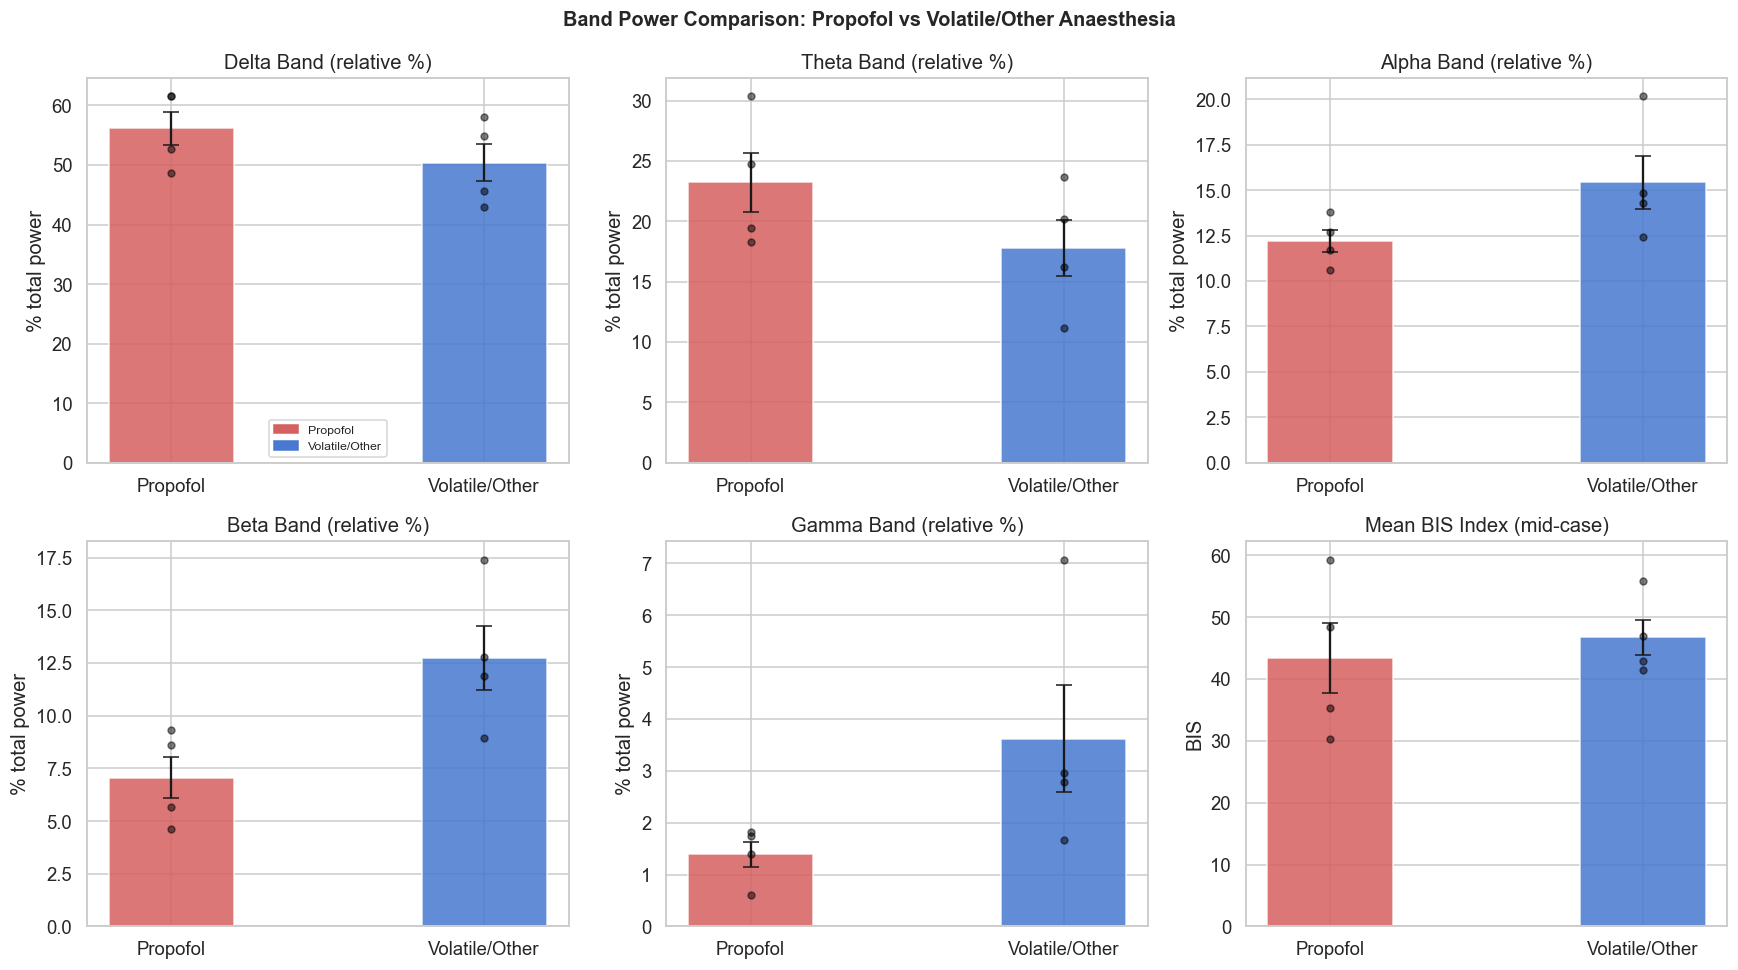

In [9]:
# ── Cell 9: Population analysis — propofol vs volatile anaesthesia ────────────
print('Anaesthetic agent breakdown in fetched cases:')
print(cases_meta['has_ppf'].value_counts().to_dict())

# Compute mid-case band powers for each case (middle 30 min)
pop_records = []
for cid, df in eeg_data.items():
    n_mid  = len(df) // 2
    n_half = min(MAX_ANALYSIS_N // 2, n_mid)
    seg    = df.iloc[max(0, n_mid - n_half) : n_mid + n_half]
    ef     = preprocess(seg['eeg1'].values)
    if len(ef) < EPOCH_N:
        continue
    freqs_p, psd_p = welch(ef, fs=FS, nperseg=EPOCH_N)
    total_p = np.trapezoid(psd_p[(freqs_p>=0.5)&(freqs_p<=45)],
                        freqs_p[(freqs_p>=0.5)&(freqs_p<=45)])
    row = {'caseid': cid}
    for bname, (flo, fhi) in BANDS.items():
        idx  = (freqs_p >= flo) & (freqs_p <= fhi)
        bpow = np.trapezoid(psd_p[idx], freqs_p[idx])
        row[f'{bname}_abs'] = bpow
        row[f'{bname}_rel'] = 100 * bpow / (total_p + 1e-10)
    if 'bis' in seg.columns:
        row['bis_mean'] = np.nanmean(seg['bis'].values)
    # Suppression ratio
    _, sup, _, _ = detect_burst_suppression(ef)
    row['sr_overall'] = 100 * np.mean(sup)
    pop_records.append(row)

pop_df = pd.DataFrame(pop_records)
pop_df = pop_df.merge(cases_meta[['caseid','has_ppf','age']], on='caseid', how='left')
print(f'\nPopulation dataframe: {pop_df.shape}')
print(pop_df[['caseid','has_ppf','alpha_rel','delta_rel',
              'bis_mean' if 'bis_mean' in pop_df.columns else 'alpha_rel',
              'sr_overall']].round(1).to_string(index=False))

palette = {'Propofol': '#D65F5F', 'Volatile/Other': '#4878CF'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, bname in enumerate(BANDS):
    col = f'{bname}_rel'
    if col not in pop_df.columns:
        continue
    grp_data = [(grp, sub[col].values) for grp, sub in pop_df.groupby('has_ppf') if len(sub) > 0]
    for j, (grp, vals) in enumerate(grp_data):
        axes[i].bar(j, np.mean(vals),
                    yerr=np.std(vals)/max(np.sqrt(len(vals)), 1),
                    color=palette.get(grp, 'gray'), width=0.4, capsize=5, alpha=0.85)
        axes[i].scatter([j]*len(vals), vals, color='black', s=20, alpha=0.5, zorder=5)
    axes[i].set(title=f'{bname.capitalize()} Band (relative %)',
                ylabel='% total power', xticks=range(len(grp_data)),
                xticklabels=[g for g, _ in grp_data])
    if i == 0:
        from matplotlib.patches import Patch
        axes[i].legend(handles=[Patch(color=c, label=k) for k, c in palette.items()], fontsize=8)

if 'bis_mean' in pop_df.columns:
    grp_data = [(grp, sub['bis_mean'].dropna().values)
                for grp, sub in pop_df.groupby('has_ppf')]
    for j, (grp, vals) in enumerate(grp_data):
        if len(vals) == 0:
            continue
        axes[5].bar(j, np.mean(vals),
                    yerr=np.std(vals)/max(np.sqrt(len(vals)), 1),
                    color=palette.get(grp, 'gray'), width=0.4, capsize=5, alpha=0.85)
        axes[5].scatter([j]*len(vals), vals, color='black', s=20, alpha=0.5, zorder=5)
    axes[5].set(title='Mean BIS Index (mid-case)', ylabel='BIS',
                xticks=range(len(grp_data)),
                xticklabels=[g for g, _ in grp_data])
else:
    axes[5].text(0.5, 0.5, 'BIS unavailable', ha='center', va='center')

plt.suptitle('Band Power Comparison: Propofol vs Volatile/Other Anaesthesia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig9_population.png', bbox_inches='tight')
plt.show()

### Do propofol and volatile agents look different on the EEG?

The bar charts above compare the relative band power and mean BIS index between propofol-based and volatile/other anaesthetic techniques. What should you look for?

- **Alpha band:** Propofol is renowned for producing strong **frontal alpha oscillations** (8–13 Hz) at moderate anaesthetic depths. If the propofol group shows higher relative alpha power, this is the classic propofol "alpha signature" in action.
- **Delta band:** Both groups should show high delta power (this is deep anaesthesia, after all), but the balance between delta and alpha may differ.
- **Beta and gamma bands:** These tend to be suppressed under both techniques, but subtle differences can exist.
- **BIS values:** If the mean BIS is similar between groups, it suggests similar overall anaesthetic depth despite potentially different spectral signatures — a reminder that BIS is a composite number that may not capture all the nuances visible in the raw spectrum.

**Clinical implication:** Different anaesthetic agents produce recognisably different EEG patterns. An anaesthesiologist who can read the raw EEG (not just the BIS number) gains additional information about the brain's state — and may be better equipped to titrate anaesthesia optimally.

> **A note on sample size:** We are comparing only 8 cases here, so these results are illustrative rather than statistically definitive. The patterns we observe are consistent with the published literature on propofol versus volatile EEG signatures.

## Can we compare EEG patterns across different patients?

So far, we have focused on a single demo case for many of our visualisations. But every patient is different — different age, different anaesthetic drugs, different surgical stimulation. Do the spectral patterns we have described hold up across multiple patients?

Below, we generate a **spectrogram gallery** — side-by-side spectrograms for four surgical cases, each spanning the entire operation. The BIS index is overlaid in white so you can see how the processed EEG number relates to the raw spectral content. This is a powerful way to develop your "EEG eye" — learning to recognise patterns visually across diverse cases.

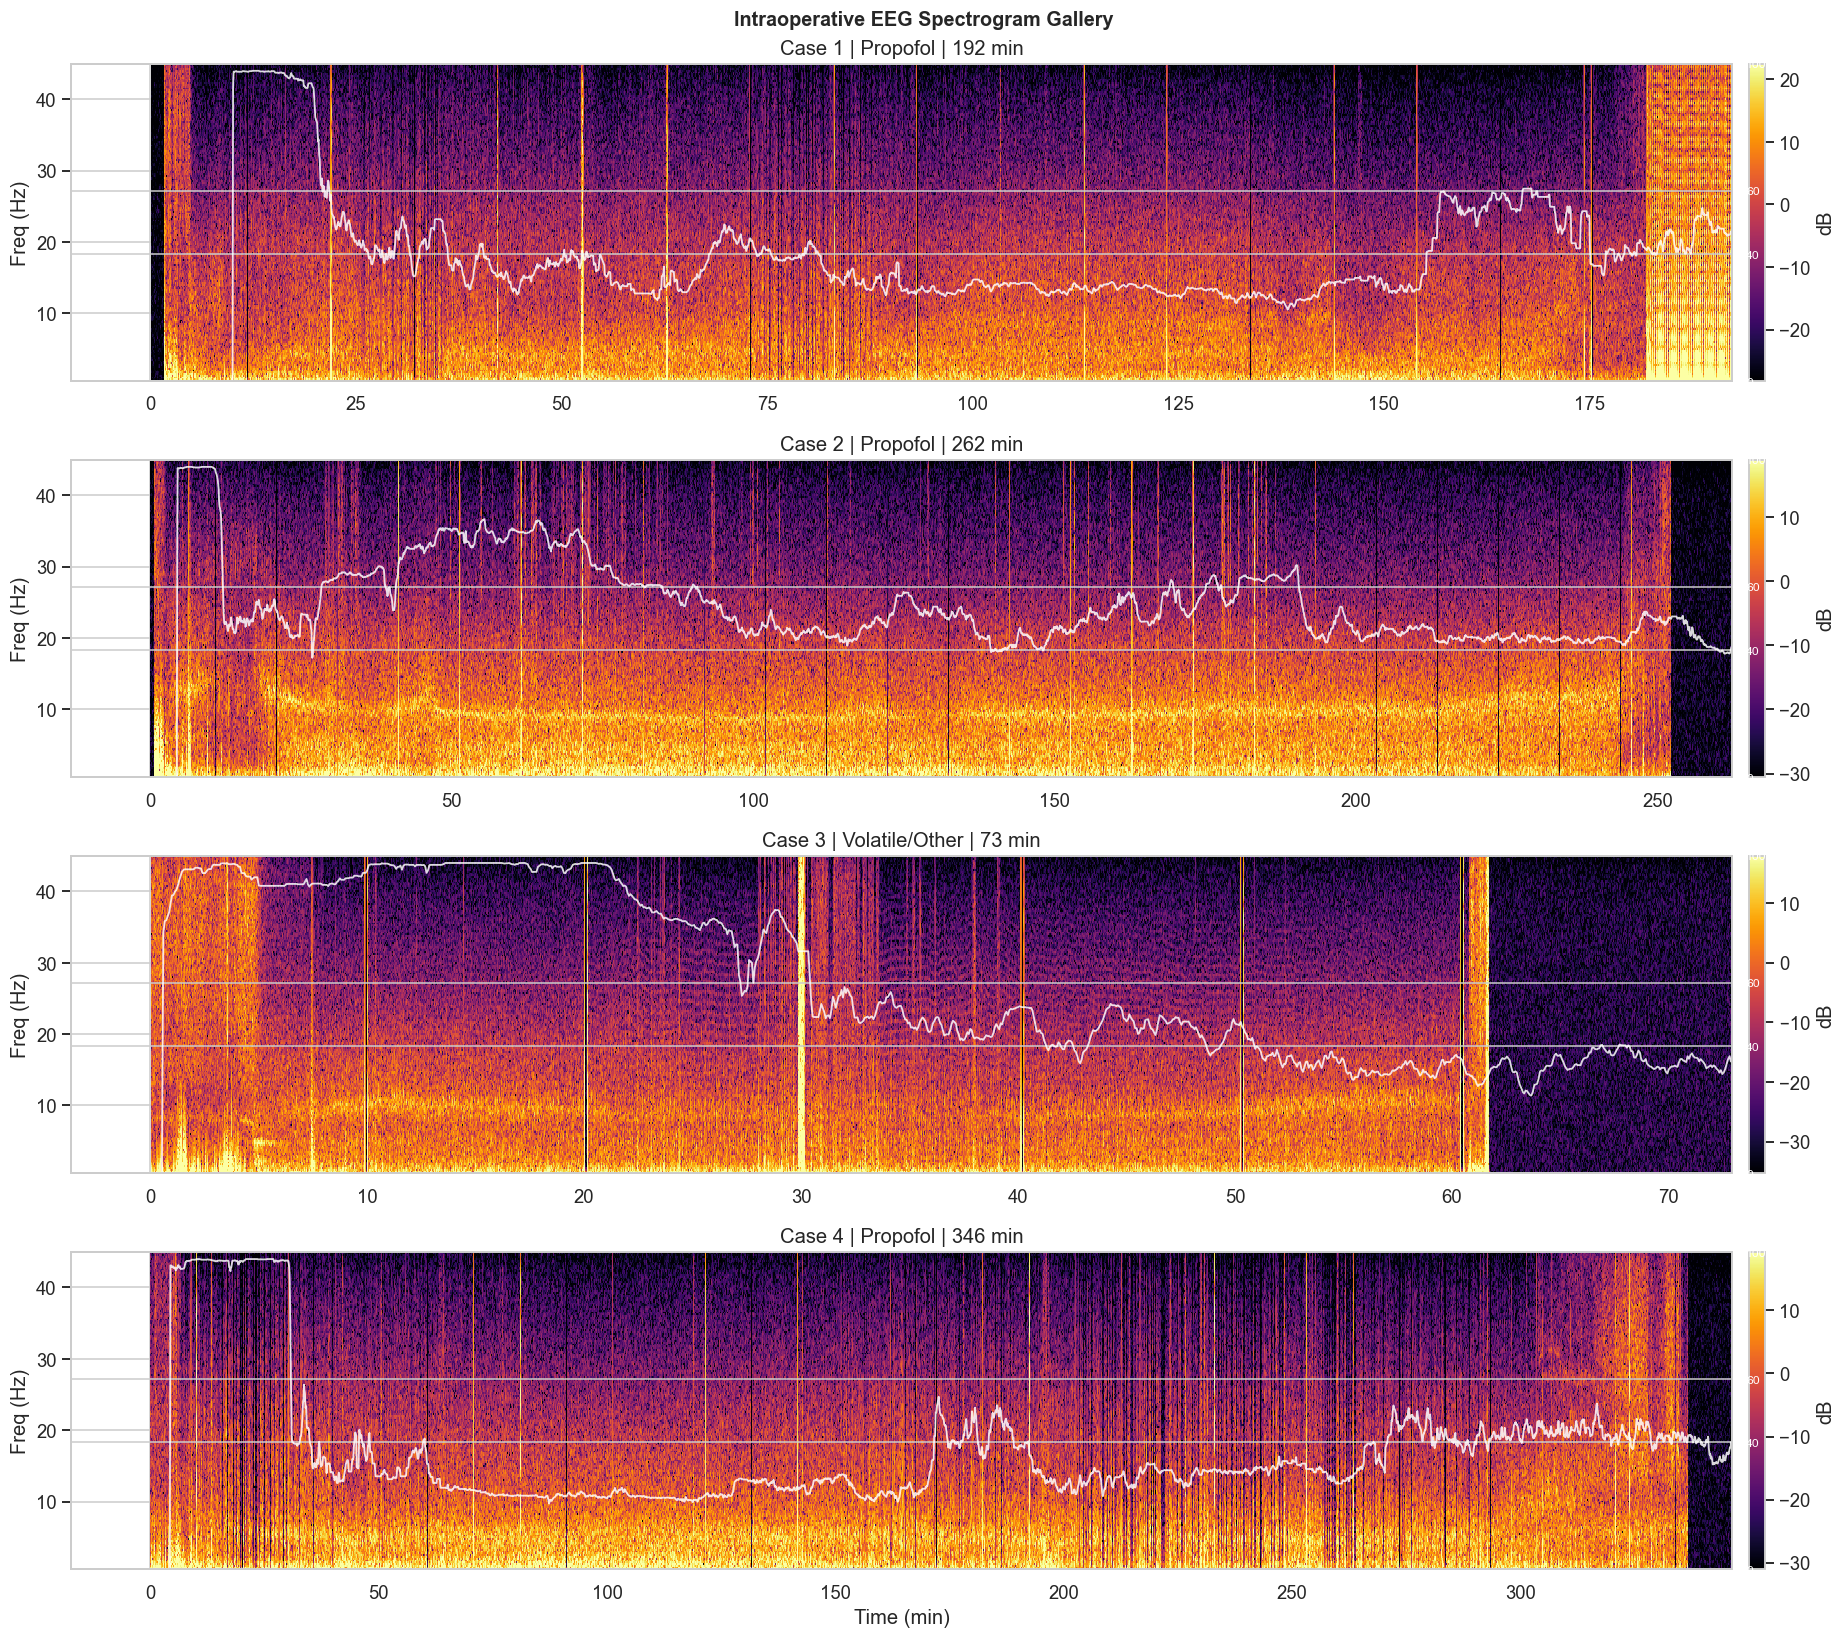

In [10]:
# ── Cell 10: Multi-case EEG spectrograms — comparison gallery ────────────────
# Show 4-case spectrogram grid for visual comparison
display_cases = list(eeg_data.keys())[:min(4, len(eeg_data))]
fig, axes = plt.subplots(len(display_cases), 1,
                          figsize=(17, 3.8 * len(display_cases)), sharex=False)
if len(display_cases) == 1:
    axes = [axes]

for ax, cid in zip(axes, display_cases):
    df_c     = eeg_data[cid]
    eeg_filt = preprocess(df_c['eeg1'].values)

    f_sg, t_sg, Sxx = spectrogram(
        eeg_filt, fs=FS, nperseg=EPOCH_N, noverlap=EPOCH_N-64,
        window='hann', scaling='density'
    )
    t_sg_min = (df_c['time_s'].values[0] + t_sg) / 60
    f_mask   = (f_sg >= 0.5) & (f_sg <= 45)
    Sxx_db   = 10 * np.log10(Sxx[f_mask, :] + 1e-12)
    vmin     = np.percentile(Sxx_db, 5)
    vmax     = np.percentile(Sxx_db, 99)

    im = ax.pcolormesh(t_sg_min, f_sg[f_mask], Sxx_db,
                        cmap='inferno', shading='auto',
                        vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='dB')

    # Overlay BIS as white line on secondary y-axis
    if 'bis' in df_c.columns:
        ax2 = ax.twinx()
        bis_idx = np.arange(0, len(df_c), int(FS*4))
        ax2.plot(df_c['time_s'].values[bis_idx]/60, df_c['bis'].values[bis_idx],
                 lw=1.2, color='white', alpha=0.85, label='BIS')
        ax2.set_ylim(0, 100)
        ax2.set_yticks([0,40,60,100])
        ax2.tick_params(axis='y', colors='white', labelsize=8)
        ax2.set_ylabel('BIS', color='white', fontsize=8)

    # Anaesthetic label
    agent = cases_meta.set_index('caseid')['has_ppf'].get(cid, 'Unknown')
    ax.set(ylabel='Freq (Hz)',
           title=f'Case {cid} | {agent} | {df_c["time_s"].max()/60:.0f} min')
    ax.set_ylim(0.5, 45)
    if ax == axes[-1]:
        ax.set_xlabel('Time (min)')

plt.suptitle('Intraoperative EEG Spectrogram Gallery', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'eeg_fig10_gallery.png', bbox_inches='tight')
plt.show()

### What does the spectrogram gallery tell us?

Each row above shows an entire surgical case as a spectrogram, with the BIS index overlaid in white. A few things to notice:

- **Every case has its own "fingerprint."** No two spectrograms look identical — patient factors (age, comorbidities, baseline brain activity) and anaesthetic technique all leave their mark on the EEG.
- **Common patterns emerge nonetheless.** In most cases, you can see the induction phase (a rapid shift from fast to slow frequencies), a maintenance plateau (dominated by delta and theta, often with a visible alpha band), and sometimes lightening or deepening events.
- **BIS tracks the spectral changes.** When the spectrogram shows more slow-wave activity, BIS tends to be lower. When faster frequencies reappear, BIS rises. This is the relationship that the BIS algorithm exploits.
- **Duration varies enormously** — from about one hour to nearly six hours — reminding us that intraoperative EEG monitoring needs to be robust over long time periods.

This kind of visual comparison is invaluable when learning to read EEG patterns. With practice, you can glance at a spectrogram and quickly assess anaesthetic depth, identify burst suppression episodes, and spot potential awareness events — all without relying solely on a single number.

## Wrapping up: What have we learned?

Let us pull together the key findings from our analysis and print a concise summary of everything we have done. This final cell collects the numbers in one place — think of it as the "results table" you would find at the end of a research paper.

In [11]:
# ── Cell 11: Summary statistics ──────────────────────────────────────────────
print('=' * 60)
print('EEG WAVEFORM ANALYSIS — SUMMARY')
print('=' * 60)
print(f'Cases analysed       : {len(eeg_data)}')
print(f'Sampling rate        : {FS} Hz')
print(f'Epoch length         : {EPOCH_S} s ({EPOCH_N} samples)')
print(f'Bandpass filter      : 0.5–45 Hz + 60 Hz notch')
print()

print('Signal quality:')
print(qc_df[['caseid','duration_min','rms_median_uV','pct_flat','pct_clip']]
      .round(2).to_string(index=False))
print()

print(f'Median case duration : {qc_df["duration_min"].median():.1f} min')
print(f'Median EEG1 RMS      : {qc_df["rms_median_uV"].median():.1f} µV')
print()

print('Burst suppression:')
sr_vals_pop = [bs_results[c]['overall_sr'] for c in bs_results]
print(f'  Mean SR  : {np.mean(sr_vals_pop):.1f}%')
print(f'  Max SR   : {np.max(sr_vals_pop):.1f}%')
print(f'  Cases with SR>10%: {sum(v>10 for v in sr_vals_pop)}')
print()

if not pop_df.empty:
    print('Mid-case band powers (mean across cases):')
    for b in BANDS:
        col = f'{b}_rel'
        if col in pop_df:
            print(f'  {b:6s}: {pop_df[col].mean():.1f}% ± {pop_df[col].std():.1f}%')

print()
print('Figures saved:')
for fig_name in ['eeg_fig3_rawsignal.png','eeg_fig4_psd.png','eeg_fig5_spectrogram.png',
                 'eeg_fig6_bs.png','eeg_fig7_bandpower.png','eeg_fig8_coherence.png',
                 'eeg_fig9_population.png','eeg_fig10_gallery.png']:
    p = BASE / fig_name
    status = f'{p.stat().st_size//1024} KB' if p.exists() else 'MISSING'
    print(f'  {fig_name}: {status}')
print()
print('Cache:')
cached = list(EEG_CACHE.glob('*.parquet'))
print(f'  {len(cached)} cases cached in {EEG_CACHE}')

EEG WAVEFORM ANALYSIS — SUMMARY
Cases analysed       : 8
Sampling rate        : 128.0 Hz
Epoch length         : 4.0 s (512 samples)
Bandpass filter      : 0.5–45 Hz + 60 Hz notch

Signal quality:
 caseid  duration_min  rms_median_uV  pct_flat  pct_clip
      1        192.33          12.10       0.0       0.0
      2        262.32          13.61       0.0       0.0
      3         72.93           7.37       0.0       0.0
      4        346.31          12.19       0.0       0.0
      5        358.72           5.68       0.0       0.0
      6         58.03          17.81       0.0       0.0
      7        120.51          14.30       0.0       0.0
      8         98.60          13.71       0.0       0.0

Median case duration : 156.4 min
Median EEG1 RMS      : 12.9 µV

Burst suppression:
  Mean SR  : 12.5%
  Max SR   : 41.9%
  Cases with SR>10%: 3

Mid-case band powers (mean across cases):
  delta : 53.3% ± 7.1%
  theta : 20.5% ± 5.8%
  alpha : 13.8% ± 2.9%
  beta  : 9.9% ± 4.1%
  gamma : 2

## Key takeaways for the clinician

Let us step back from the code and summarise what we have learned about the anaesthetised brain:

### 1. The EEG tells you more than the BIS number
The BIS index is a useful summary, but it is a single number derived from a rich, complex signal. By looking at the raw EEG and its spectral content, you can understand *why* the BIS is at a particular value — and sometimes detect problems (artefact, burst suppression, paradoxical responses) that the BIS number alone might miss.

### 2. Anaesthesia shifts brain activity from fast to slow
The most consistent finding across all our cases is the **dominance of slow-wave (delta) activity** under general anaesthesia, accounting for over 50% of total EEG power. This reflects the widespread cortical inhibition produced by anaesthetic drugs.

### 3. Frontal alpha is a hallmark of moderate-depth propofol anaesthesia
The alpha band (8–13 Hz) carries important clinical information. Its presence suggests adequate but not excessive anaesthetic depth. Its disappearance may herald either lightening (if beta increases) or deepening (if only delta remains).

### 4. Burst suppression is a warning sign
In our cohort, 3 out of 8 cases showed significant burst suppression (SR > 10%). This pattern — the brain intermittently going electrically silent — indicates excessive anaesthetic depth and has been linked to adverse postoperative outcomes, particularly in the elderly.

### 5. Different agents, different EEG signatures
Propofol and volatile agents produce recognisably different spectral patterns. Understanding these differences helps you interpret EEG-based monitors appropriately, regardless of the anaesthetic technique.

### Where to go from here
In the next chapters, we will build on these concepts to explore **pharmacokinetic-pharmacodynamic (PK/PD) modelling** of propofol (Chapter 13.1) and the relationship between anaesthetic depth, haemodynamics, and clinical outcomes (Chapter 11.2). The EEG analysis skills you have developed here will serve as a foundation for understanding how anaesthetic drugs interact with the brain at a quantitative level.